In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")
import pandas as pd
from utils import ca as cu, behave as bu, plot as pu, db as db, tune as tune, misc as mu
from utils.stats import calc_selectivity_index
import numpy as np
from paths.config import M2PConfig
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import plotly.express as px
from scipy.stats import ranksums, wilcoxon
from dataclasses import dataclass
from typing import List, Tuple, Optional
import os

In [5]:
cfg = M2PConfig()
df_exps, df_roi, df_ca, df_behave, df_behave_ca = db.get_ca_behave_data(cfg, 
                                                                        exclude_bad_behave=False, 
                                                                        exclude_bad_2p=False,
                                                                        min_ear_dist=None,
                                                                        max_ear_dist=None, #40
                                                                        calc_extra_behave=True,)

In [6]:
grp_df_behave = df_behave.groupby(['exp_id', 'animal_id'])

In [7]:
@dataclass
class DecisionRule:
    """Defines a decision point detection rule."""
    start_condition: Tuple[int, int]  # (x, y) coordinates for start
    end_conditions: List[Tuple[int, int]]  # List of possible (x, y) end coordinates
    mid_condition: Tuple[int, int]  # (x, y) coordinates for mid point
    is_t: bool = False  # Whether this is a T-junction
    is_left: bool = None  # Whether this is a left turn
    allo_dir: float = None  # ENSW as 0, 90, 180, 270
    name: Optional[str] = None

    @property
    def id(self) -> str:
        tstr = 'T' if self.is_t else 'nonT'
        leftstr = 'L' if self.is_left else 'R' if self.is_left is not None else 'NA'
        allostr = self.allo_dir if self.allo_dir is not None else 'NA'
        return f"{tstr}_{leftstr}_{allostr}_{str(self.start_condition)}_{str(self.mid_condition)}"

COL_DECISION_ID: str = 'decision_id'
COL_DECISION_ID_FULL: str = 'decision_id_full'
COL_DECISION_ID_MID: str = 'decision_id_mid'
COL_DECISION_ID_PRE: str = 'decision_id_pre'
COL_DECISION_ID_POST: str = 'decision_id_post'
COL_DECISION_START: str = 'decision_start'
COL_DECISION_EGO: str = 'decision_ego'
COL_DECISION_ALLO: str = 'decision_allo'
COL_DECISION_RULE_ID: str = 'decision_rule_id'


HEAD_X_FILT_MAZE_COORDS: str = 'head_x_filt_maze_coords'
HEAD_Y_FILT_MAZE_COORDS: str = 'head_y_filt_maze_coords'


def detect_decision_points(df: pd.DataFrame, 
                           rules: List[DecisionRule],
                           decision_counter: int,
                           ) -> pd.DataFrame:
    """
    Detect decision points and add decision numbers to dataframe.
    
    Args:
        df: Input dataframe
        rules: List of DecisionRule objects
        decision_col: Name of column to create for decision numbers
        
    Returns:
        DataFrame with added decision number column
    """
    # Create a copy to avoid modifying original
    df_result = df.copy(deep=True).reset_index(drop=True)

    decisions_list = []
    
    # Calculate integer coordinates (ceiling)
    x_coords = np.ceil(df_result[bu.HEAD_X_FILT_MAZE]).astype(int)
    y_coords = np.ceil(df_result[bu.HEAD_Y_FILT_MAZE]).astype(int)

    df_result[HEAD_X_FILT_MAZE_COORDS] = x_coords
    df_result[HEAD_Y_FILT_MAZE_COORDS] = y_coords
    
    # Initialize decision column
    df_result[COL_DECISION_ID_FULL] = None
    df_result[COL_DECISION_ID_MID] = None
    df_result[COL_DECISION_ID_PRE] = None
    df_result[COL_DECISION_ID_POST] = None
    df_result[COL_DECISION_START] = None
    df_result[COL_DECISION_RULE_ID] = None
    
    
    # Process each rule
    for rule in rules:
        start_x, start_y = rule.start_condition
        end_x1, end_y1 = rule.end_conditions[0]  # Assuming at least one end condition
        end_x2, end_y2 = rule.end_conditions[1]  # Assuming at least one end condition
        mid_x, mid_y = rule.mid_condition

        search_idx = 0
        while search_idx < len(df_result):

            x_coords_search = x_coords[search_idx:]
            y_coords_search = y_coords[search_idx:]
        
            # Find the first occurrence of the start condition
            start_idx = get_next_index(x_coords_search, y_coords_search, start_x, start_y)
            if start_idx is None:
                #print("No more start conditions found")
                break
            df_start_idx = search_idx + start_idx
            search_idx += start_idx
            
            x_coords_search = x_coords[search_idx:]
            y_coords_search = y_coords[search_idx:]
            
            # Find the next time the mouse leaves the start condition
            leave_start_idx = get_next_index(x_coords_search, y_coords_search, start_x, start_y, negate=True)
            if leave_start_idx is None:
                break
            else:
                next_x = x_coords_search.iloc[leave_start_idx]
                next_y = y_coords_search.iloc[leave_start_idx]

                search_idx += leave_start_idx + 1

                # If the next position is not the mid coord, skip this start point
                if not (next_x == mid_x and next_y == mid_y):
                    continue

            df_mid_idx = df_start_idx + leave_start_idx
   
            x_coords_search = x_coords[search_idx:]
            y_coords_search = y_coords[search_idx:]
                
            # Look for next coord after this mid point
            leave_mid_idx = get_next_index(x_coords_search, y_coords_search, mid_x, mid_y, negate=True)
            if leave_mid_idx is None:
                continue
            else:
                next_x = x_coords_search.iloc[leave_mid_idx]
                next_y = y_coords_search.iloc[leave_mid_idx]

                search_idx += leave_mid_idx + 1

                # If the next position is not part of the end conditions OR the start conditions, skip this start point
                if not (next_x == end_x1 and next_y == end_y1) and not (next_x == end_x2 and next_y == end_y2) and not (next_x == start_x and next_y == start_y):
                    #print("Did not exit to an end condition or start condition, must be tracking error, skipping")
                    continue
            #print(f"Found decision point: start at {df_start_idx}, mid at {df_mid_idx}, next at {search_idx-1}")

            df_end_idx = df_mid_idx + leave_mid_idx

            x_coords_search = x_coords[search_idx:]
            y_coords_search = y_coords[search_idx:]

            # Look for next coord after this end point
            leave_end_idx = get_next_index(x_coords_search, y_coords_search, next_x, next_y, negate=True)
            if leave_end_idx is None:
               search_idx = len(df_result)  # End the search
            else:
               search_idx += leave_end_idx + 1

            df_post_idx = df_end_idx + leave_mid_idx
    
            df_result.loc[df_start_idx:df_end_idx, COL_DECISION_ID_FULL] = decision_counter
            df_result.loc[df_mid_idx:df_end_idx, COL_DECISION_ID_MID] = decision_counter
            df_result.loc[df_start_idx:df_mid_idx-1, COL_DECISION_ID_PRE] = decision_counter
            df_result.loc[df_end_idx+1:df_post_idx, COL_DECISION_ID_POST] = decision_counter
            

            duration_full = (df_end_idx - df_start_idx) * 0.1 # Assuming 0.1s per frame
            duration_mid = (df_end_idx - df_mid_idx) * 0.1 # Assuming 0.1s per frame
            duration_pre = (df_mid_idx - df_start_idx) * 0.1
            duration_post = (df_post_idx - df_end_idx) * 0.1

            coord_start_x = x_coords.iloc[df_start_idx]
            coord_start_y = y_coords.iloc[df_start_idx]
            coord_mid_x = x_coords.iloc[df_mid_idx]
            coord_mid_y = y_coords.iloc[df_mid_idx]
            coord_end_x = x_coords.iloc[df_end_idx]
            coord_end_y = y_coords.iloc[df_end_idx]

            coord_diff_x = coord_end_x - coord_mid_x
            coord_diff_y = coord_end_y - coord_mid_y
            
            decision_allo = None
            if coord_diff_x < 0:
                decision_allo = 180 # West
            elif coord_diff_x > 0:
                decision_allo = 0 # East
            elif coord_diff_y < 0:
                decision_allo = 270 # South
            elif coord_diff_y > 0:
                decision_allo = 90 # North
            else:
                raise ValueError("No coordinate change detected in decision point.")
            
            # Determine ego direction which is an angle from 0 to 360, where 0 is right, 90 is forward, 180 is left, 270 is backward
            # Use the mid point to end point vector to determine this

            # Calculate heading direction (start to mid)
            heading_x = coord_mid_x - coord_start_x
            heading_y = coord_mid_y - coord_start_y

            # Calculate movement direction (mid to end) 
            movement_x = coord_diff_x
            movement_y = coord_diff_y

            # Get angles in degrees
            heading_angle = np.degrees(np.arctan2(heading_y, heading_x))
            movement_angle = np.degrees(np.arctan2(movement_y, movement_x))

            # Calculate relative angle and convert to ego frame (0=right, 90=forward, 180=left, 270=backward)
            decision_ego = (movement_angle - heading_angle + 90) % 360
         

            data_dict = {"exp_id": df_result.iloc[0]["exp_id"],
                         "animal_id": df_result.iloc[0]["animal_id"],
                         COL_DECISION_ID: decision_counter,
                         "is_left": rule.is_left,
                         "allo_dir": rule.allo_dir,
                         "is_t": rule.is_t,
                         "start_x": start_x,
                         "start_y": start_y,
                         "end_x": end_x1,
                         "end_y": end_y1,
                         "mid_x": mid_x,
                         "mid_y": mid_y,
                         COL_DECISION_EGO: decision_ego,
                         COL_DECISION_ALLO: decision_allo,
                         "duration_full": duration_full,
                         "duration_mid": duration_mid,
                         "duration_pre": duration_pre,
                         "duration_post": duration_post,
                         COL_DECISION_RULE_ID: rule.id,
                         }
            
            
            
            decisions_list.append(data_dict)

            decision_counter += 1

    df_decisions = pd.DataFrame(decisions_list)

    # unique_decisions = df_result[COL_DECISION_ID_FULL].dropna().unique()
    # unique_decisions = np.sort(unique_decisions)
    # print(f"Unique decisions in df_result: {unique_decisions}")
            
    return df_result, df_decisions, decision_counter

def get_next_index(x_coords, y_coords, x_val, y_val, negate=False):
    if negate:
        next_indexes = (x_coords != x_val) | (y_coords != y_val)
    else:
        next_indexes = (x_coords == x_val) & (y_coords == y_val)
    if next_indexes.sum() == 0:
        next_index =  None
    else:
        next_index = np.where(next_indexes)[0][0]

    if negate and next_index is not None:
        next_index += 1  # Move to the next index after the found one

    return next_index


rules = [

    # Bottom left
    DecisionRule(
        start_condition=(1, 1),
        mid_condition=(2, 1),
        end_conditions=[(3, 1), (2, 2)],
        is_left=True,
        allo_dir=180,
        name=""
    ),
    DecisionRule(
        start_condition=(3, 1),
        mid_condition=(2, 1),
        end_conditions=[(1, 1), (2, 2)],
        is_left=False,
        allo_dir=0,
        name=""
    ),

    # Left middle
    DecisionRule(
        start_condition=(2, 2),
        mid_condition=(2, 3),
        end_conditions=[(2, 4), (3, 3)],
        is_left=False,
        allo_dir=270,
        name=""
    ),
    DecisionRule(
        start_condition=(2, 4),
        mid_condition=(2, 3),
        end_conditions=[(2, 2), (3, 3)],
        is_left=True,
        allo_dir=90,
        name=""
    ),

    # Top left
    DecisionRule(
        start_condition=(1, 5),
        mid_condition=(2, 5),
        end_conditions=[(3, 5), (2, 4)],
        is_left=False,
        allo_dir=180,
        name=""
    ),
    DecisionRule(
        start_condition=(3, 5),
        mid_condition=(2, 5),
        end_conditions=[(1, 5), (2, 4)],
        is_left=True,
        allo_dir=0,
        name=""
    ),


    # Bottom right
    DecisionRule(
        start_condition=(5, 1),
        mid_condition=(6, 1),
        end_conditions=[(7, 1), (6, 2)],
        is_left=True,
        allo_dir=180,
        name=""
    ),
    DecisionRule(
        start_condition=(7, 1),
        mid_condition=(6, 1),
        end_conditions=[(5, 1), (6, 2)],
        is_left=False,
        allo_dir=0,
        name=""
    ),

    # Right middle
    DecisionRule(
        start_condition=(6, 2),
        mid_condition=(6, 3),
        end_conditions=[(6, 4), (5, 3)],
        is_left=False,
        allo_dir=270,
        name=""
    ),
    DecisionRule(
        start_condition=(6, 4),
        mid_condition=(6, 3),
        end_conditions=[(6, 2), (5, 3)],
        is_left=True,
        allo_dir=90,
        name=""
    ),

    # Top right
    DecisionRule(
        start_condition=(5, 5),
        mid_condition=(6, 5),
        end_conditions=[(7, 5), (6, 4)],
        is_left=False,
        allo_dir=0,
        name=""
    ),
    DecisionRule(
        start_condition=(7, 5),
        mid_condition=(6, 5),
        end_conditions=[(5, 5), (6, 4)],
        is_left=True,
        allo_dir=180,
        name=""
    ),

    # Middle
    DecisionRule(
        start_condition=(3, 3),
        mid_condition=(4, 3),
        end_conditions=[(4, 4), (5, 3)],
        is_left=True,
        allo_dir=180,
        name=""
    ),
    DecisionRule(
        start_condition=(5, 3),
        mid_condition=(4, 3),
        end_conditions=[(4, 4), (3, 3)],
        is_left=True,
        allo_dir=0,
        name=""
    ),

    # T-junctions
    DecisionRule(
        start_condition=(4, 4),
        mid_condition=(4, 3),
        end_conditions=[(3, 3), (5, 3)],
        is_t=True,
        allo_dir=90,
        name=""
    ),

    DecisionRule(
        start_condition=(3, 3),
        mid_condition=(2, 3),
        end_conditions=[(2, 4), (2, 2)],
        is_t=True,
        allo_dir=180,
        name=""
    ),

    DecisionRule(
        start_condition=(5, 3),
        mid_condition=(6, 3),
        end_conditions=[(6, 4), (6, 2)],
        is_t=True,
        allo_dir=0,
        name=""
    ),

    DecisionRule(
        start_condition=(2, 4),
        mid_condition=(2, 5),
        end_conditions=[(1, 5), (3, 5)],
        is_t=True,
        allo_dir=90,
        name=""
    ),

    DecisionRule(
        start_condition=(6, 4),
        mid_condition=(6, 5),
        end_conditions=[(5, 5), (7, 5)],
        is_t=True,
        allo_dir=90,
        name=""
    ),

    DecisionRule(
        start_condition=(2, 2),
        mid_condition=(2, 1),
        end_conditions=[(1, 1), (3, 1)],
        is_t=True,
        allo_dir=270,
        name=""
    ),

    DecisionRule(
        start_condition=(6, 2),
        mid_condition=(6, 1),
        end_conditions=[(5, 1), (7, 1)],
        is_t=True,
        allo_dir=270,
        name=""
    ),
    
]





In [8]:
def merge_exclude_duplicates(left_df, right_df, how='left', left_on=None, right_on=None, on=None):
    """
    Merge two dataframes while automatically excluding duplicate columns from the right dataframe.
    
    Parameters:
    -----------
    left_df : pd.DataFrame
        Left dataframe
    right_df : pd.DataFrame
        Right dataframe
    how : str, default 'left'
        Type of merge to perform
    left_on : list or str, optional
        Column(s) from left dataframe to merge on
    right_on : list or str, optional
        Column(s) from right dataframe to merge on
    on : list or str, optional
        Column(s) to merge on (when column names are the same in both dataframes)
    
    Returns:
    --------
    pd.DataFrame
        Merged dataframe without duplicate columns
    """
    # Handle the 'on' parameter
    if on is not None:
        left_on = on if isinstance(on, list) else [on]
        right_on = on if isinstance(on, list) else [on]
    else:
        # Ensure left_on and right_on are lists
        left_on = left_on if isinstance(left_on, list) else [left_on]
        right_on = right_on if isinstance(right_on, list) else [right_on]
    
    # Select only non-duplicate columns from right_df (keeping merge keys)
    cols_to_keep = right_on + [col for col in right_df.columns 
                                if col not in left_df.columns 
                                and col not in right_on]
    
    # Perform the merge
    return left_df.merge(
        right_df[cols_to_keep],
        how=how,
        left_on=left_on,
        right_on=right_on
    )

('20210823_16_59_50_1114353', 1114353, 1)
('20211028_11_25_50_1115465', 1115465, 438)
('20211203_15_10_27_1115464', 1115464, 612)
('20220408_15_01_57_1116663', 1116663, 781)
('20220608_15_27_32_1117217', 1117217, 1034)
('20220608_16_22_06_1116994', 1116994, 1398)
('20220802_15_06_53_1117646', 1117646, 1573)
('20221003_14_36_54_1118020', 1118020, 1785)
('20221018_10_56_17_1117788', 1117788, 2356)
('20221115_13_27_42_1118213', 1118213, 2693)
('20221116_14_31_12_1118320', 1118320, 3177)


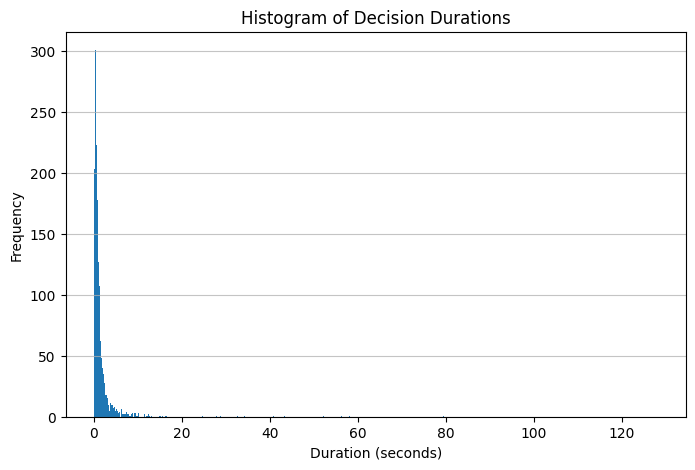

1th percentile: 0.10 seconds
5th percentile: 0.10 seconds
25th percentile: 0.40 seconds
50th percentile: 0.70 seconds
75th percentile: 1.50 seconds
95th percentile: 5.30 seconds
99th percentile: 15.58 seconds


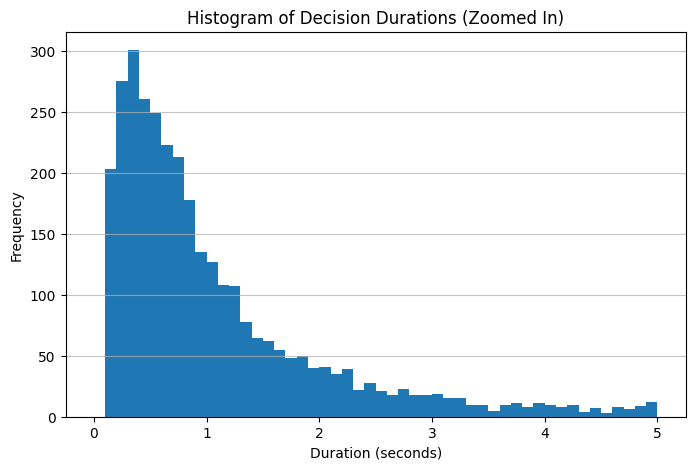

In [9]:

# Initialize lists to accumulate results
all_df_behave_decisions = []
all_df_decisions = []

decision_counter = 1

for (exp_id, animal_id), df_group in grp_df_behave:
    print((exp_id, animal_id, decision_counter))

    df_behave_decisions_temp, df_decisions_temp, decision_counter = detect_decision_points(
        df_group, 
        rules=rules,
        decision_counter=decision_counter,
    )
    
    # Accumulate results
    all_df_behave_decisions.append(df_behave_decisions_temp)
    all_df_decisions.append(df_decisions_temp)


# Concatenate all results
df_behave_decisions = pd.concat(all_df_behave_decisions, ignore_index=True)
df_decisions = pd.concat(all_df_decisions, ignore_index=True)

# Plot a histogram of decision durations
plt.figure(figsize=(8, 5))
# Space the bins in 0.1 increments starting from 0 to max duration
bins = np.arange(0, df_decisions["duration_mid"].max() + 0.1, 0.1)
plt.hist(df_decisions["duration_mid"], bins=bins)
plt.title('Histogram of Decision Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()
# Print, 1st, 5th, 95th and 99th percentiles of decision durations
percentiles = [1, 5, 25, 50, 75, 95, 99]
percentile_values = np.percentile(df_decisions["duration_mid"], percentiles)
for p, value in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {value:.2f} seconds")

# Plot a zoomed in version of the histogram up to 5s
plt.figure(figsize=(8, 5))
# Space the bins in 0.1 increments starting from 0 to 5s
bins = np.arange(0, 5.1, 0.1)
plt.hist(df_decisions["duration_mid"], bins=bins)
plt.title('Histogram of Decision Durations (Zoomed In)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [10]:


# Filter any decision longer than 2s
df_decisions = df_decisions[df_decisions["duration_mid"] <= 2.0]
df_decisions = df_decisions[df_decisions["duration_pre"] <= 2.0]

# # Joint df_behave_decisions to df_decisions on animal_id, exp_id, and decision_id
# df_behave_decisions = df_behave_decisions.merge(df_decisions, 
#                                                 how='left', 
#                                                 left_on=['animal_id', 'exp_id', COL_DECISION_ID_FULL], 
#                                                 right_on=['animal_id', 'exp_id', COL_DECISION_ID],
#                                                 suffixes=('', '_dec'))


df_behave_decisions = merge_exclude_duplicates(
    df_behave_decisions,
    df_decisions,
    how='inner',
    left_on=['animal_id', 'exp_id', COL_DECISION_ID_FULL],
    right_on=['animal_id', 'exp_id', COL_DECISION_ID]
)

print("Done")

unique_decisions = df_behave_decisions[COL_DECISION_ID_MID].dropna().unique()
unique_decisions = np.sort(unique_decisions)
print(f"Unique decisions in df_behave_decisions before merge : {unique_decisions}")




Done
Unique decisions in df_behave_decisions before merge : [1 2 4 ... 3410 3415 3420]


In [11]:
# Debug: Check the shapes and unique values before and after merge
print(f"df_behave_decisions shape before merge: {df_behave_decisions.shape}")
print(f"df_decisions shape before merge: {df_decisions.shape}")
print(f"Unique decision numbers in df_decisions: {sorted(df_decisions[COL_DECISION_ID].unique())}")

# Check if there are any decision numbers in df_behave_decisions that don't exist in df_decisions
decision_nums_in_behave = df_behave_decisions[COL_DECISION_ID_FULL].dropna().unique()
decision_nums_in_decisions = df_decisions[COL_DECISION_ID].unique()

print(f"Decision numbers in df_behave_decisions: {len(decision_nums_in_behave)}")
print(f"Decision numbers in df_decisions: {len(decision_nums_in_decisions)}")

# Check for mismatches
missing_in_decisions = set(decision_nums_in_behave) - set(decision_nums_in_decisions)
missing_in_behave = set(decision_nums_in_decisions) - set(decision_nums_in_behave)

if missing_in_decisions:
    print(f"Decision numbers in behave data but missing in decisions data: {missing_in_decisions}")
if missing_in_behave:
    print(f"Decision numbers in decisions data but missing in behave data: {len(missing_in_behave)} decisions")
    print(f"First 10 missing: {sorted(list(missing_in_behave))[:10]}")

# Check the merge keys
print("\nMerge key combinations in df_behave_decisions:")
behave_keys = df_behave_decisions[['animal_id', 'exp_id', COL_DECISION_ID_FULL]].dropna()
unique_behave_combos = behave_keys.drop_duplicates()
print(f"Unique (animal_id, exp_id, decision_id) combinations: {len(unique_behave_combos)}")

print("\nMerge key combinations in df_decisions:")
decision_keys = df_decisions[['animal_id', 'exp_id', COL_DECISION_ID]].drop_duplicates()
print(f"Unique (animal_id, exp_id, {COL_DECISION_ID}) combinations: {len(decision_keys)}")

df_behave_decisions shape before merge: (34540, 122)
df_decisions shape before merge: (2150, 19)
Unique decision numbers in df_decisions: [1, 4, 5, 6, 7, 8, 12, 13, 21, 22, 27, 28, 30, 31, 33, 34, 36, 37, 38, 39, 40, 41, 42, 43, 46, 47, 48, 49, 50, 52, 53, 54, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 67, 71, 72, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 99, 101, 103, 104, 105, 106, 107, 112, 113, 115, 120, 121, 123, 124, 126, 127, 128, 132, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 148, 152, 153, 154, 155, 157, 162, 163, 164, 165, 166, 167, 168, 169, 170, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 190, 194, 195, 196, 197, 198, 207, 208, 209, 210, 212, 214, 220, 222, 223, 224, 225, 226, 227, 229, 231, 232, 235, 238, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 252, 253, 254, 255, 256, 258, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 277, 279, 280, 281, 282, 283, 284, 2

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


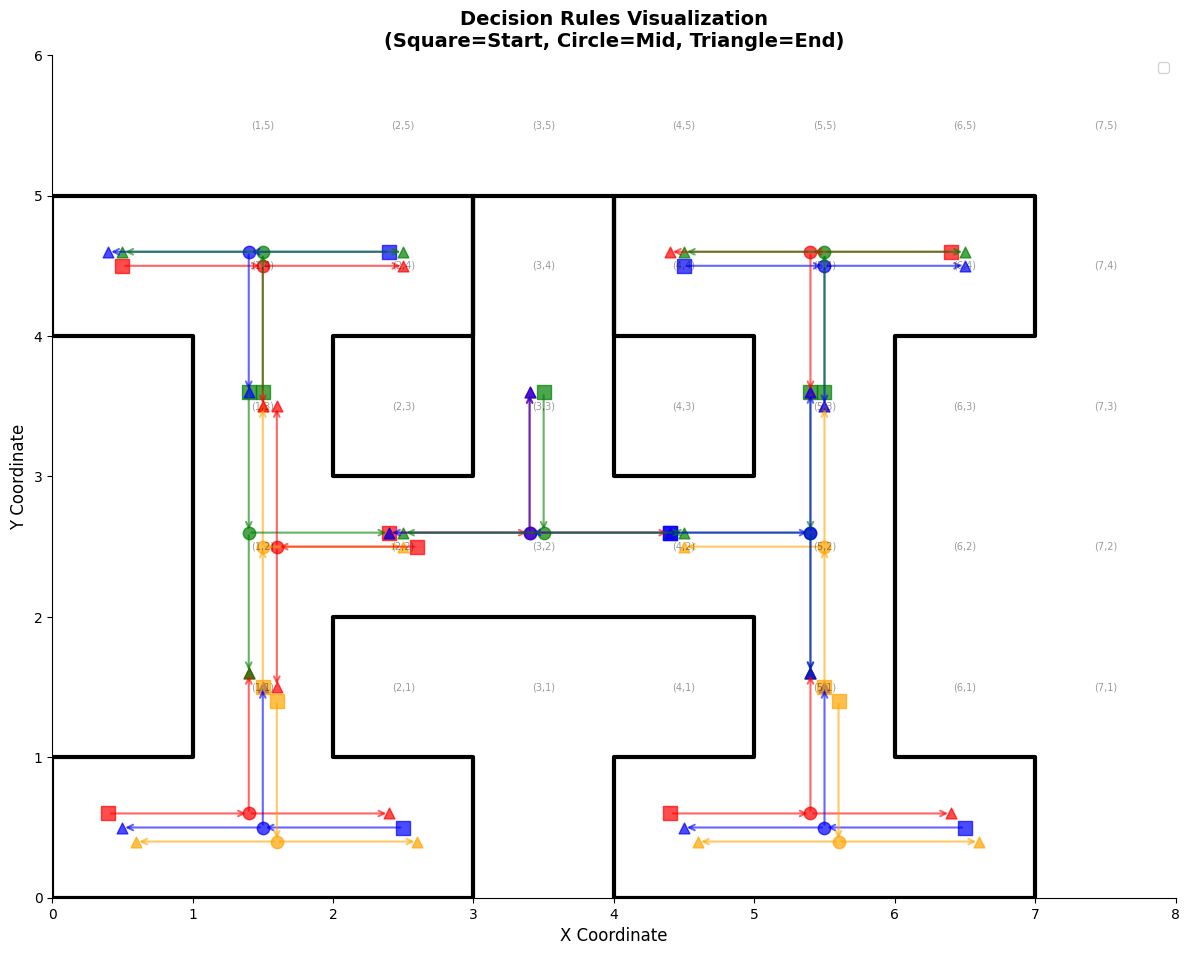

Decision Rules Summary:
Total rules: 21
Direction distribution:
  0: 6 rules
  90: 5 rules
  180: 6 rules
  270: 4 rules

Decision types:
  Left decisions: 8
  T-junction decisions: 7
  Other decisions: 6


In [12]:
# Create the plot of the decision rules
fig, ax = plt.subplots(figsize=(12, 10))

# Color mapping for different types of decisions
color_map = {
    0: 'blue',    # East
    180: 'red',     # West
    90: 'green',   # North
    270: 'orange'   # South
}

# Plot each decision rule
for i, rule in enumerate(rules):
    color = color_map[rule.allo_dir]
    
    # Plot start condition (minus 0.5 to coordinates)
    offset_x = 0.5
    offset_y = 0.5
    if rule.is_left:
        offset_x = 0.6
        offset_y = 0.4
    elif rule.is_t:
        if rule.allo_dir == 90: # North
            offset_x = 0.5
            offset_y = 0.4
        elif rule.allo_dir == 0: # East
            offset_x = 0.6
            offset_y = 0.4
        elif rule.allo_dir == 180: # West
            offset_x = 0.4
            offset_y = 0.5
        else: # South
            offset_x = 0.4
            offset_y = 0.6

    start_x, start_y = rule.start_condition[0] - offset_x, rule.start_condition[1] - offset_y   
    ax.scatter(start_x, start_y, c=color, s=100, marker='s', alpha=0.7)
    
    # Plot mid condition (minus 0.5 to coordinates)
    mid_x, mid_y = rule.mid_condition[0] - offset_x, rule.mid_condition[1] - offset_y
    ax.scatter(mid_x, mid_y, c=color, s=80, marker='o', alpha=0.7)
    
    # Plot end conditions (minus 0.5 to coordinates)
    for end_pos in rule.end_conditions:
        end_x, end_y = end_pos[0] - offset_x, end_pos[1] - offset_y
        ax.scatter(end_x, end_y, c=color, s=60, marker='^', alpha=0.7)
    
    # Draw arrows from start to mid to each end condition
    # Start to mid
    ax.annotate('', xy=(mid_x, mid_y), xytext=(start_x, start_y),
                arrowprops=dict(arrowstyle='->', color=color, alpha=0.6, lw=1.5))
    
    # Mid to each end condition
    for end_pos in rule.end_conditions:
        end_x, end_y = end_pos
        end_x, end_y = end_x - offset_x, end_y - offset_y
        ax.annotate('', xy=(end_x, end_y), xytext=(mid_x, mid_y),
                    arrowprops=dict(arrowstyle='->', color=color, alpha=0.6, lw=1.5))
    
    # # Add rule index label near the start position
    # ax.text(start_x + 0.1, start_y + 0.1, f'R{i}', fontsize=8, alpha=0.8)

# Customize the plot
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)
ax.set_title('Decision Rules Visualization\n(Square=Start, Circle=Mid, Triangle=End)', fontsize=14, fontweight='bold')

# Turn off top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Turn off grid
ax.grid(False)

ax.legend(loc='upper right')

# Set equal aspect ratio and adjust limits
ax.set_aspect('equal')
ax.set_xlim(0, 8)
ax.set_ylim(0, 6)

# Add coordinate labels
for x in range(1, 8):
    for y in range(1, 6):
        ax.text(x + 0.5, y + 0.5, f'({x},{y})', fontsize=7, ha='center', va='center', alpha=0.4)

maze_poly = bu.get_maze_poly()          
maze_poly_x, maze_poly_y = maze_poly.exterior.coords.xy
plt.plot(np.array(maze_poly_x), np.array(maze_poly_y), 'k', linewidth=3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Decision Rules Summary:")
print(f"Total rules: {len(rules)}")
print(f"Direction distribution:")
for direction in [0, 90, 180, 270]:
    count = sum(1 for rule in rules if rule.allo_dir == direction)
    print(f"  {direction}: {count} rules")

print(f"\nDecision types:")
left_count = sum(1 for rule in rules if hasattr(rule, 'is_left') and rule.is_left)
t_count = sum(1 for rule in rules if hasattr(rule, 'is_t') and rule.is_t)
print(f"  Left decisions: {left_count}")
print(f"  T-junction decisions: {t_count}")
print(f"  Other decisions: {len(rules) - left_count - t_count}")

Unique decisions in filtered data: [1 3 6 ... 3410 3415 3420]


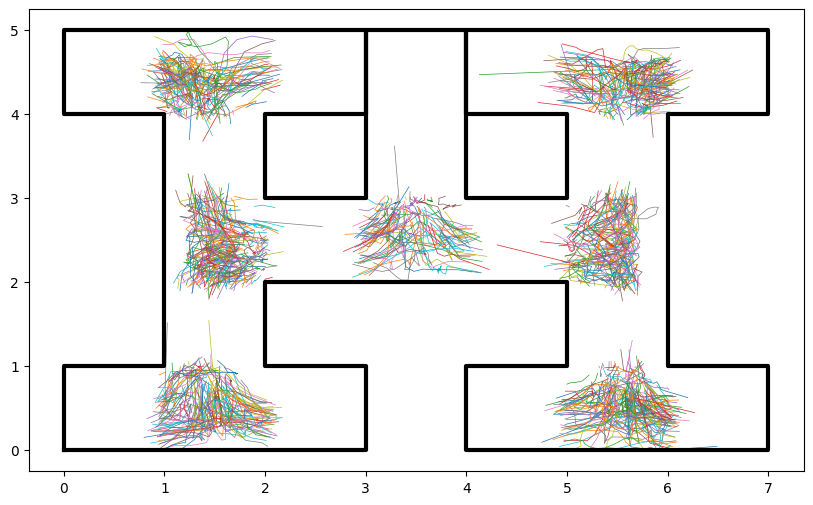

In [13]:
#df_with_decisions_filt = df_behave_decisions
#df_with_decisions_filt = df_behave_decisions[(df_behave_decisions[COL_DECISION_ALLO] == 180) & (df_behave_decisions["is_left"] == True)]
df_with_decisions_filt = df_behave_decisions[(df_behave_decisions["is_t"] == True)]
#df_with_decisions_filt = df_behave_decisions[(df_behave_decisions["is_t"] == False) & (df_with_decisions["is_left"] == True)]
#df_with_decisions_filt = df_behave_decisions[(df_behave_decisions["is_t"] == True) & (df_with_decisions["decision_allo_dec"] == "N")]
# Get all the unique decision numbers
unique_decisions = df_with_decisions_filt[COL_DECISION_ID_PRE].dropna().unique()
unique_decisions = np.sort(unique_decisions)
print(f"Unique decisions in filtered data: {unique_decisions}")

plt.figure(figsize=(10, 6))
for decision_num in unique_decisions:
    if decision_num == 0:
        continue  # Skip non-decision rows
    df_decision = df_with_decisions_filt[df_with_decisions_filt[COL_DECISION_ID_MID] == decision_num]
    #print(f"Decision {decision_num}:")
    
    plt.plot(df_decision[bu.HEAD_X_FILT_MAZE], df_decision[bu.HEAD_Y_FILT_MAZE], alpha=1, linewidth=0.5)

maze_poly = bu.get_maze_poly()          
maze_poly_x, maze_poly_y = maze_poly.exterior.coords.xy
plt.plot(np.array(maze_poly_x), np.array(maze_poly_y), 'k', linewidth=3)
plt.show()

In [14]:
duration_col = "duration_mid"
decision_id_col = COL_DECISION_ID_MID
# duration_col = "duration_full"
# decision_id_col = COL_DECISION_ID_FULL
# duration_col = "duration_pre"
# decision_id_col = DECISION_ID_PRE_COL
# duration_col = "duration_post"
# decision_id_col = DECISION_ID_POST_COL

# Print the total number of decisions detected for t_shape and non-t_shape, for left and right non t_shapes
print("Total decisions detected:", len(df_decisions))
print("Total T-shape decisions detected:", df_decisions['is_t'].sum())
print("Total left turn decisions detected (non T-shape):", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['is_left'] ==  True)]))
print("Total right turn decisions detected (non T-shape):", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['is_left'] ==  False)]))

# Print total left and right turn from N, E, S, W allo direction (non t_shapes)
print("Total left turn decisions from N allo direction:", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['allo_dir'] == 90) & (df_decisions['is_left'] == True)]))
print("Total right turn decisions from N allo direction:", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['allo_dir'] == 90) & (df_decisions['is_left'] == False)]))
print("Total left turn decisions from E allo direction:", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['allo_dir'] == 0) & (df_decisions['is_left'] == True)]))
print("Total right turn decisions from E allo direction:", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['allo_dir'] == 0) & (df_decisions['is_left'] == False)]))
print("Total left turn decisions from S allo direction:", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['allo_dir'] == 270) & (df_decisions['is_left'] == True)]))
print("Total right turn decisions from S allo direction:", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['allo_dir'] == 270) & (df_decisions['is_left'] == False)]))
print("Total left turn decisions from W allo direction:", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['allo_dir'] == 180) & (df_decisions['is_left'] == True)]))
print("Total right turn decisions from W allo direction:", len(df_decisions[(df_decisions['is_t'] == False) & (df_decisions['allo_dir'] == 180) & (df_decisions['is_left'] == False)]))

# Print the number of times each decision was made
decision_counts = df_decisions[COL_DECISION_EGO].value_counts().sort_index()
print("\nNumber of times each decision was made:")
for decision_dir, count in decision_counts.items():
    print(f"Decision {decision_dir}: {count} times")

# Print the number of times each allo direction was chosen
allo_counts = df_decisions[COL_DECISION_ALLO].value_counts().sort_index()
print("\nNumber of times each allo direction was chosen:")
for allo_dir, count in allo_counts.items():
    print(f"Allo direction {allo_dir}: {count} times")

# Print total time of data frame and total time in decisions, and percentage of time in decisions
total_time = len(df_behave) * 0.1  # Assuming 10 Hz sampling rate
total_decision_time = df_decisions[duration_col].sum()
percentage_time_in_decisions = (total_decision_time / total_time) * 100
print(f"Total time in data frame: {total_time/60:.2f} minutes")
print(f"Total time in decisions: {total_decision_time/60:.2f} minutes")
print(f"Percentage of time in decisions: {percentage_time_in_decisions:.2f}%")
# Calculate total time moving and percentage of time moving that is decisions
moving_indexes = bu.get_moving_indexes(df_behave_decisions)
total_moving_time = np.sum(moving_indexes) * 0.1  # Assuming 10 Hz sampling rate
percentage_moving_time_in_decisions = (total_decision_time / total_moving_time) * 100
print(f"Total time moving: {total_moving_time/60:.2f} minutes")
print(f"Percentage of moving time in decisions: {percentage_moving_time_in_decisions:.2f}%")


Total decisions detected: 2150
Total T-shape decisions detected: 879
Total left turn decisions detected (non T-shape): 792
Total right turn decisions detected (non T-shape): 479
Total left turn decisions from N allo direction: 281
Total right turn decisions from N allo direction: 0
Total left turn decisions from E allo direction: 193
Total right turn decisions from E allo direction: 135
Total left turn decisions from S allo direction: 0
Total right turn decisions from S allo direction: 303
Total left turn decisions from W allo direction: 318
Total right turn decisions from W allo direction: 41

Number of times each decision was made:
Decision 0.0: 551 times
Decision 90.0: 602 times
Decision 180.0: 609 times
Decision 270.0: 388 times

Number of times each allo direction was chosen:
Allo direction 0: 577 times
Allo direction 90: 516 times
Allo direction 180: 575 times
Allo direction 270: 482 times
Total time in data frame: 324.30 minutes
Total time in decisions: 25.68 minutes
Percentage 

In [15]:
RESPONSE_TYPE = cu.CA_DECONV_NORM
#RESPONSE_TYPE = cu.CA_DECONV_NORM_CLEAN
#RESPONSE_TYPE = cu.CA_EVENTS_ONSET
#RESPONSE_TYPE = cu.CA_EVENTS_AMP
#RESPONSE_TYPE = cu.CA_EVENTS_MASK

# Set this to false to use probability of events rather than event rate.
EVENTS_ONSET_AS_RATE = False

# Roll the neural data by this number of frames to break tuning.
BREAKING_OFFSET_FRAMES = None #

# If set to true then use the event masks to remove all detected events.
REMOVE_EVENTS = False

PLOT_ROI_PLOTS = False
PLOT_DPI = 100
PLOT_SUM_DPI = 300

RESPONSE_COL = RESPONSE_TYPE #+ "-time"

# Interleave test is getting some interleaved blocks of time and calculating tuning to see if they match.
# In seconds, 1/4 of the light on time
INTERLEAVE_TIME = 15
TWOP_FPS = 10 # Typical
INTERLEAVE_INDEXES = int(round(INTERLEAVE_TIME * TWOP_FPS))

MIN_ROLL_FRAMES = 200

N_LAGS_FRAMES = 10 * TWOP_FPS
# Don't know why this yucky grid is on
plt.style.use(['default'])
plt.rcParams['axes.grid'] = False
plt.rcParams.update({'font.size': 12})




In [16]:
# if RESPONSE_TYPE == cu.CA_EVENTS_ONSET:
#     # Get events in events per minutes
#     if EVENTS_ONSET_AS_RATE:
#         # Convert to probability of an event
#         df_ca[RESPONSE_COL] = df_ca[RESPONSE_TYPE] * df_behave_ca["fps_2p"] * 60
#     else:
#         df_ca[RESPONSE_COL] = df_ca[RESPONSE_TYPE] * 100
        
# elif RESPONSE_TYPE == cu.CA_EVENTS_MASK:
#     # Convert to %
#     df_ca[RESPONSE_COL] = df_ca[RESPONSE_TYPE] * 100
# else:
#     # Change signal to be per second instead of per frame
#     df_ca[RESPONSE_COL] = df_ca[RESPONSE_TYPE] * df_behave_ca["fps_2p"]
    
if REMOVE_EVENTS:
    df_ca[RESPONSE_COL] = df_ca[RESPONSE_TYPE] * (1 - df_behave_ca[cu.CA_EVENTS_MASK])
    

# Join behave to ca data
df_ca_behave_decisions = df_ca.merge(df_behave_decisions, 
                                     on=['exp_id', 'frame_id'], 
                                     how='inner',
                                     suffixes=('_ca', ''))
print(f"Behave with decisions shape: {df_behave_decisions.shape}")
print(f"CA with behave decisions shape: {df_ca_behave_decisions.shape}")




Behave with decisions shape: (34540, 122)
CA with behave decisions shape: (489328, 177)


In [17]:
# Caclulate the total number of event onsets in df_ca_behave_decisions
total_event_onsets = df_ca['event_onset'].sum()
print(f"Total event onsets: {total_event_onsets}")
# Calculate the total number of event onsets during decisions
event_onsets_during_decisions = df_ca_behave_decisions[df_ca_behave_decisions[decision_id_col].notna()]['event_onset'].sum()
print(f"Event onsets during decisions: {event_onsets_during_decisions}")
# Calculate percentage of event onsets during decisions
percentage_event_onsets_during_decisions = (event_onsets_during_decisions / total_event_onsets) * 100
print(f"Percentage of event onsets during decisions: {percentage_event_onsets_during_decisions:.2f}%")
# Calculate the percentage of events during movement
moving_indexes_ca = bu.get_moving_indexes(df_behave_ca)
total_moving_time_ca = np.sum(moving_indexes_ca) * 0.1  # Assuming 10 Hz sampling rate
event_onsets_during_movement = df_behave_ca[moving_indexes_ca]['event_onset'].sum()
percentage_event_onsets_during_movement = (event_onsets_during_movement / total_event_onsets) * 100
print(f"Total time moving in CA data: {total_moving_time_ca/60:.2f} minutes")
print(f"Event onsets during movement: {event_onsets_during_movement}")
print(f"Percentage of event onsets during movement: {percentage_event_onsets_during_movement:.2f}%")

# Caclulate the mean ca trace during decisions and not during decisions
mean_ca_during_decisions = df_ca_behave_decisions[df_ca_behave_decisions[decision_id_col].notna()][cu.CA_DECONV_NORM].mean()
mean_ca_not_during_decisions = df_ca_behave_decisions[df_ca_behave_decisions[decision_id_col].isna()][cu.CA_DECONV_NORM].mean()
print(f"Mean CA during decisions: {mean_ca_during_decisions:.4f}")
print(f"Mean CA not during decisions: {mean_ca_not_during_decisions:.4f}")

Total event onsets: 11153.0
Event onsets during decisions: 1287.0
Percentage of event onsets during decisions: 11.54%
Total time moving in CA data: 3393.64 minutes
Event onsets during movement: 9682.0
Percentage of event onsets during movement: 86.81%
Mean CA during decisions: 0.0107
Mean CA not during decisions: 0.0111


In [18]:
grp_df_cell = df_ca_behave_decisions.groupby(['exp_id', 'animal_id', 'roi_id', 'celltype', 'roi_type'])

In [ ]:
@dataclass
class DecData:
    tjunc_sel: float
    tjunc_p: float
    tjunc_n1: int
    tjunc_n2: int

    tjunc_sel_pre: float
    tjunc_p_pre: float
    tjunc_n1_pre: int
    tjunc_n2_pre: int

    tjunc_light_sel: float
    tjunc_light_p: float
    tjunc_light_n1: int
    tjunc_light_n2: int

    tjunc_dark_sel: float
    tjunc_dark_p: float
    tjunc_dark_n1: int
    tjunc_dark_n2: int

    tjunc_light_sel_pre: float
    tjunc_light_p_pre: float
    tjunc_light_n1_pre: int
    tjunc_light_n2_pre: int

    tjunc_dark_sel_pre: float
    tjunc_dark_p_pre: float
    tjunc_dark_n1_pre: int
    tjunc_dark_n2_pre: int

    lr_sel: float
    lr_p: float
    lr_n1: int
    lr_n2: int

    lr_sel_pre: float
    lr_p_pre: float
    lr_n1_pre: int
    lr_n2_pre: int

    lr_light_sel: float
    lr_light_p: float
    lr_light_n1: int
    lr_light_n2: int

    lr_dark_sel: float
    lr_dark_p: float
    lr_dark_n1: int
    lr_dark_n2: int

    # ls_sel: float
    # ls_p: float
    # ls_n: int

    # rs_sel: float
    # rs_p: float
    # rs_n: int

    # rs_sel_pre: float
    # rs_p_pre: float
    # rs_n_pre: int

    # lr_sel_pre: float
    # lr_p_pre: float
    # lr_n_pre: int


def average_arrays(arrays, from_front=True):
    # Find maximum length
    max_len = max(len(arr) for arr in arrays)
    # Create padded array filled with NaN
    padded = np.full((len(arrays), max_len), np.nan)
    # Fill in the values
    for i, arr in enumerate(arrays):
        if from_front:
            padded[i, :len(arr)] = arr
        else:
            padded[i, -len(arr):] = arr
    # Compute mean ignoring NaN
    avg = np.nanmean(padded, axis=0)
    return avg

@dataclass
class DecStats:
    sel: float
    sel_p: float
    n1: int
    n2: int

def calc_dec_metrics(df,
                     col_dec,
                     dec1,
                     dec2,
                     col_dec_period,
                     title=None,
                     plot_path=None):


    # Group df by the decision id and dec_col and calculate the mean response for each decision
    grp_by_cols = [col_dec_period, col_dec]
    df_grp_dec = df.groupby(grp_by_cols, dropna=False)[RESPONSE_COL].mean().reset_index()
 
    resp1 = df_grp_dec[df_grp_dec[col_dec] == dec1][RESPONSE_COL]
    resp2 = df_grp_dec[df_grp_dec[col_dec] == dec2][RESPONSE_COL]  

    resp1_mean = resp1.mean()
    resp2_mean = resp2.mean()  

    n1 = len(resp1)
    n2 = len(resp2)

    sel_p = np.nan
    sel = np.nan
    if n1 >= 3 and n2 >= 3:
    
        sel = calc_selectivity_index(resp1_mean, resp2_mean)

        sel_p = 1


    if False: #plot_path:

        #zero_at_end = col_dec_period == COL_DECISION_ID_PRE
        zero_at_end = True

        plt.figure(figsize=(16, 4))
        ax1 = plt.subplot(1, 3, 1)

        maze_poly = bu.get_maze_poly()          
        maze_poly_x, maze_poly_y = maze_poly.exterior.coords.xy
        ax1.plot(np.array(maze_poly_x), np.array(maze_poly_y), 'k', linewidth=3)

        # Find the unique decision numbers in the df
        unique_decisions = df[col_dec_period].dropna().unique()
        unique_decisions.sort()
        
        for d in unique_decisions:
            
            df_dec = df[df[col_dec_period] == d]

            if df_dec[col_dec].values[0] == dec1:
                dec_label=dec1
                dec_color=pu.COLOR_DEC1
            elif df_dec[col_dec].values[0] == dec2:
                dec_label=dec2
                dec_color=pu.COLOR_DEC2
            else:
                continue

            ax1.plot(df_dec[bu.HEAD_X_FILT_MAZE],
                     df_dec[bu.HEAD_Y_FILT_MAZE],
                     label=dec_label,
                     color=dec_color,
                     alpha=0.7)
        

        ax2 = plt.subplot(1, 3, 2)

        # Store traces for averaging
        traces_dec1 = []
        traces_dec2 = []

        for d in unique_decisions:
            
            df_dec = df[df[col_dec_period] == d]

            if df_dec[col_dec].values[0] == dec1:
                dec_color = pu.COLOR_DEC1
                trace = df_dec[RESPONSE_COL].values
                traces_dec1.append(trace)
                time_axis = np.arange(len(trace)) * 0.1
                
                        
            elif df_dec[col_dec].values[0] == dec2:
                dec_color = pu.COLOR_DEC2
                trace = df_dec[RESPONSE_COL].values
                traces_dec2.append(trace)
                time_axis = np.arange(len(trace)) * 0.1

            else:
                continue
                
            if zero_at_end:
                time_axis = time_axis - time_axis[-1]
            ax2.plot(time_axis,
                     trace,
                     color=dec_color,
                     alpha=0.3,
                     linewidth=0.5)


        
        average_arrays_dec1 = average_arrays(traces_dec1, from_front=~zero_at_end)
        average_arrays_dec2 = average_arrays(traces_dec2, from_front=~zero_at_end)
        time_axis_avg1 = np.arange(len(average_arrays_dec1)) * 0.1
        time_axis_avg2 = np.arange(len(average_arrays_dec2)) * 0.1
        if zero_at_end:
            time_axis_avg1 = time_axis_avg1 - time_axis_avg1[-1]
            time_axis_avg2 = time_axis_avg2 - time_axis_avg2[-1]

        ax2.plot(time_axis_avg1,
                 average_arrays_dec1,
                 label=f'Avg {dec1}',
                 color=pu.COLOR_DEC1,
                 alpha=1.0,
                 linewidth=2.0)
        ax2.plot(time_axis_avg2,
                 average_arrays_dec2,
                 label=f'Avg {dec2}',
                 color=pu.COLOR_DEC2,
                 alpha=1.0,
                 linewidth=2.0)
        
        ymax = 1.1 * max(np.max(average_arrays_dec1), np.max(average_arrays_dec2))
        ax2.set_ylim(0, ymax)

        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Response')
        ax2.legend()

        ax2.set_title(f"Sel={sel:.2f}, p={sel_p:.3f}, n1={n1}, n2={n2}")

        ax3 = plt.subplot(1, 3, 3)
        trace_dec1_means = []
        trace_dec2_means = []
        for trace in traces_dec1:
            trace_dec1_means.append(trace.mean())
        for trace in traces_dec2:
            trace_dec2_means.append(trace.mean())
        p_value =pu.plot_box_celltype(df_roi,
                             penk_data=trace_dec1_means,
                             nonpenk_data=trace_dec2_means,
                             plot_label='T-junction Mean Response',
                             labels=[0, 180],
                             create_new_figure=False,
                             show_plot=False,
                             do_ranksums=True
                            )
        sel_p = p_value
        plt.tight_layout()
        #plt.show()
        plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white')
        plt.close()
        is_sig = sel_p < 0.05
        if is_sig: 
            mu.copy2dir(plot_path, cfg.sum_tune_roi_sig_path)   
            #mu.copy2dir(plot_path, cfg.sum_tune_roi_sig_path / cell_type)  
        else:
            mu.copy2dir(plot_path, cfg.sum_tune_roi_nonsig_path)
            #mu.copy2dir(plot_path, cfg.sum_tune_roi_nonsig_path / cell_type)
        

    #raise Exception("Stop here for now")

    return DecStats(sel=sel, 
                    sel_p=sel_p, 
                    n1=n1,
                    n2=n2)



def calc_dec_all(df,
                 plot_path=None,
                 ):
    
    light_indexes = bu.get_light_indexes(df)
    tjunc_indexes = df['is_t'] == True
    non_tjunc_indexes = df['is_t'] == False
    ls_indexes = (df['is_t'] == False) & (df['is_left'] == True)
    rs_indexes = (df['is_t'] == False) & (df['is_left'] == False)
    
    stats_tjunc = calc_dec_metrics(df[tjunc_indexes],
                                   col_dec=COL_DECISION_EGO,
                                   dec1=0,
                                   dec2=180,
                                   col_dec_period=COL_DECISION_ID_MID,
                                   plot_path=plot_path.replace("XXXPLOTNAMEXXX", "00_tjunc"),
                                   )
    
    stats_tjunc_pre = calc_dec_metrics(df[tjunc_indexes],
                                       col_dec=COL_DECISION_EGO,
                                       dec1=0,
                                       dec2=180,
                                       col_dec_period=COL_DECISION_ID_PRE,
                                       plot_path=plot_path.replace("XXXPLOTNAMEXXX", "03_tjunc_pre"),
                                       )
    
    stats_tjunc_light = calc_dec_metrics(df[tjunc_indexes & light_indexes],
                                         col_dec=COL_DECISION_EGO,
                                         dec1=0,
                                         dec2=180,
                                         col_dec_period=COL_DECISION_ID_MID,
                                         plot_path=plot_path.replace("XXXPLOTNAMEXXX", "01_tjunc_light"),
                                         )
    stats_tjunc_dark = calc_dec_metrics(df[tjunc_indexes & ~light_indexes],
                                        col_dec=COL_DECISION_EGO,
                                        dec1=0,
                                        dec2=180,
                                        col_dec_period=COL_DECISION_ID_MID,
                                        plot_path=plot_path.replace("XXXPLOTNAMEXXX", "02_tjunc_dark"),
                                        )
    
    stats_tjunc_light_pre = calc_dec_metrics(df[tjunc_indexes & light_indexes],
                                         col_dec=COL_DECISION_EGO,
                                         dec1=0,
                                         dec2=180,
                                         col_dec_period=COL_DECISION_ID_PRE,
                                         plot_path=plot_path.replace("XXXPLOTNAMEXXX", "01_tjunc_light_pre"),
                                         )
    stats_tjunc_dark_pre = calc_dec_metrics(df[tjunc_indexes & ~light_indexes],
                                        col_dec=COL_DECISION_EGO,
                                        dec1=0,
                                        dec2=180,
                                        col_dec_period=COL_DECISION_ID_PRE,
                                        plot_path=plot_path.replace("XXXPLOTNAMEXXX", "02_tjunc_dark_pre"),
                                        )
    
    
    
    stats_lr_nontjunc = calc_dec_metrics(df[non_tjunc_indexes],
                                            col_dec=COL_DECISION_EGO,
                                            dec1=0,
                                            dec2=180,
                                            col_dec_period=COL_DECISION_ID_MID,
                                            plot_path=plot_path.replace("XXXPLOTNAMEXXX", "04_lr_nontjunc"),
                                            )
    
    stats_lr_nontjunc_light = calc_dec_metrics(df[non_tjunc_indexes & light_indexes],
                                               col_dec=COL_DECISION_EGO,
                                               dec1=0,
                                               dec2=180,
                                               col_dec_period=COL_DECISION_ID_MID,
                                               )
    stats_lr_nontjunc_dark = calc_dec_metrics(df[non_tjunc_indexes & ~light_indexes],
                                              col_dec=COL_DECISION_EGO,
                                              dec1=0,
                                              dec2=180,
                                              col_dec_period=COL_DECISION_ID_MID,
                                              )
    
    stats_lr_nontjunc_pre = calc_dec_metrics(df[non_tjunc_indexes],
                                             col_dec=COL_DECISION_EGO,
                                             dec1=0,
                                             dec2=180,
                                             col_dec_period=COL_DECISION_ID_PRE,
                                             )
    
    stats_tjunc_by_allo = {}
    for allo_dir in [0, 90, 180, 270]:
        df_allo = df[df['allo_dir'] == allo_dir]
        this_allo_dir = calc_dec_metrics(df_allo[non_tjunc_indexes],
                                         col_dec=COL_DECISION_EGO,
                                         dec1=0,
                                         dec2=180,
                                         col_dec_period=COL_DECISION_ID_MID,
                                         )
        stats_tjunc_by_allo[allo_dir] = this_allo_dir
    
    
    
    
    return DecData(
        tjunc_sel=stats_tjunc.sel,
        tjunc_p=stats_tjunc.sel_p,
        tjunc_n1=stats_tjunc.n1,
        tjunc_n2=stats_tjunc.n2,

        tjunc_sel_pre=stats_tjunc_pre.sel,
        tjunc_p_pre=stats_tjunc_pre.sel_p,
        tjunc_n1_pre=stats_tjunc_pre.n1,
        tjunc_n2_pre=stats_tjunc_pre.n2,

        tjunc_light_sel=stats_tjunc_light.sel,
        tjunc_light_p=stats_tjunc_light.sel_p,
        tjunc_light_n1=stats_tjunc_light.n1,
        tjunc_light_n2=stats_tjunc_light.n2,

        tjunc_dark_sel=stats_tjunc_dark.sel,
        tjunc_dark_p=stats_tjunc_dark.sel_p,
        tjunc_dark_n1=stats_tjunc_dark.n1,
        tjunc_dark_n2=stats_tjunc_dark.n2,

        tjunc_light_sel_pre=stats_tjunc_light_pre.sel,
        tjunc_light_p_pre=stats_tjunc_light_pre.sel_p,
        tjunc_light_n1_pre=stats_tjunc_light_pre.n1,
        tjunc_light_n2_pre=stats_tjunc_light_pre.n2,

        tjunc_dark_sel_pre=stats_tjunc_dark_pre.sel,
        tjunc_dark_p_pre=stats_tjunc_dark_pre.sel_p,
        tjunc_dark_n1_pre=stats_tjunc_dark_pre.n1,
        tjunc_dark_n2_pre=stats_tjunc_dark_pre.n2,

        lr_sel=stats_lr_nontjunc.sel,
        lr_p=stats_lr_nontjunc.sel_p,
        lr_n1=stats_lr_nontjunc.n1,
        lr_n2=stats_lr_nontjunc.n2,

        lr_sel_pre=stats_lr_nontjunc_pre.sel,
        lr_p_pre=stats_lr_nontjunc_pre.sel_p,
        lr_n1_pre=stats_lr_nontjunc_pre.n1,
        lr_n2_pre=stats_lr_nontjunc_pre.n2,

        lr_light_sel=stats_lr_nontjunc_light.sel,
        lr_light_p=stats_lr_nontjunc_light.sel_p,
        lr_light_n1=stats_lr_nontjunc_light.n1,
        lr_light_n2=stats_lr_nontjunc_light.n2,

        lr_dark_sel=stats_lr_nontjunc_dark.sel,
        lr_dark_p=stats_lr_nontjunc_dark.sel_p,
        lr_dark_n1=stats_lr_nontjunc_dark.n1,
        lr_dark_n2=stats_lr_nontjunc_dark.n2
    )
                




In [ ]:
# Main loop to go through each cell and calculate decision tuning
for (exp_id, animal_id, roi_id, cell_type, roi_type), df_group in grp_df_cell:

    print((exp_id, animal_id, roi_id, cell_type, roi_type))
    
    #BREAKING_OFFSET_FRAMES = 100
    if BREAKING_OFFSET_FRAMES:
        df_group[RESPONSE_COL] = np.roll(df_group[RESPONSE_COL], BREAKING_OFFSET_FRAMES)

    roi_index = (df_roi['exp_id'] == exp_id) & \
                (df_roi['roi_id'] == roi_id) & \
                (df_roi['roi_type'] == roi_type)
    

    plot_name = "{}_{:03d}_{}_{}_{}_XXXPLOTNAMEXXX.png".format(exp_id,
                                                                roi_id,
                                                                roi_type,
                                                                cell_type,
                                                                RESPONSE_COL)

    plot_path = os.path.join(cfg.sum_dec_roi_path, plot_name)
    #plot_path = None # Disable plotting for now
    
    dec_data = calc_dec_all(df_group, 
                            plot_path)

 
    df_roi.loc[roi_index, 'tjunc_sel'] = dec_data.tjunc_sel
    df_roi.loc[roi_index, 'tjunc_sel_abs'] = abs(dec_data.tjunc_sel)
    df_roi.loc[roi_index, 'tjunc_p'] = dec_data.tjunc_p
    df_roi.loc[roi_index, 'tjunc_n1'] = dec_data.tjunc_n1
    df_roi.loc[roi_index, 'tjunc_n2'] = dec_data.tjunc_n2

    df_roi.loc[roi_index, 'tjunc_sel_pre'] = dec_data.tjunc_sel_pre
    df_roi.loc[roi_index, 'tjunc_sel_pre_abs'] = abs(dec_data.tjunc_sel_pre)
    df_roi.loc[roi_index, 'tjunc_p_pre'] = dec_data.tjunc_p_pre
    df_roi.loc[roi_index, 'tjunc_n1_pre'] = dec_data.tjunc_n1_pre
    df_roi.loc[roi_index, 'tjunc_n2_pre'] = dec_data.tjunc_n2_pre

    df_roi.loc[roi_index, 'tjunc_light_sel'] = dec_data.tjunc_light_sel
    df_roi.loc[roi_index, 'tjunc_light_sel_abs'] = abs(dec_data.tjunc_light_sel)
    df_roi.loc[roi_index, 'tjunc_light_p'] = dec_data.tjunc_light_p
    df_roi.loc[roi_index, 'tjunc_light_n1'] = dec_data.tjunc_light_n1
    df_roi.loc[roi_index, 'tjunc_light_n2'] = dec_data.tjunc_light_n2

    df_roi.loc[roi_index, 'tjunc_dark_sel'] = dec_data.tjunc_dark_sel
    df_roi.loc[roi_index, 'tjunc_dark_sel_abs'] = abs(dec_data.tjunc_dark_sel)
    df_roi.loc[roi_index, 'tjunc_dark_p'] = dec_data.tjunc_dark_p
    df_roi.loc[roi_index, 'tjunc_dark_n1'] = dec_data.tjunc_dark_n1     
    df_roi.loc[roi_index, 'tjunc_dark_n2'] = dec_data.tjunc_dark_n2

    # todo
    df_roi.loc[roi_index, 'tjunc_light_pre_sel'] = dec_data.tjunc_light_sel_pre
    df_roi.loc[roi_index, 'tjunc_light_pre_sel_abs'] = abs(dec_data.tjunc_light_sel_pre)
    df_roi.loc[roi_index, 'tjunc_light_pre_p'] = dec_data.tjunc_light_p_pre
    df_roi.loc[roi_index, 'tjunc_light_pre_n1'] = dec_data.tjunc_light_n1_pre
    df_roi.loc[roi_index, 'tjunc_light_pre_n2'] = dec_data.tjunc_light_n2_pre

    df_roi.loc[roi_index, 'tjunc_dark_pre_sel'] = dec_data.tjunc_dark_sel_pre
    df_roi.loc[roi_index, 'tjunc_dark_pre_sel_abs'] = abs(dec_data.tjunc_dark_sel_pre)
    df_roi.loc[roi_index, 'tjunc_dark_pre_p'] = dec_data.tjunc_dark_p_pre
    df_roi.loc[roi_index, 'tjunc_dark_pre_n1'] = dec_data.tjunc_dark_n1_pre
    df_roi.loc[roi_index, 'tjunc_dark_pre_n2'] = dec_data.tjunc_dark_n2_pre


    df_roi.loc[roi_index, 'lr_sel'] = dec_data.lr_sel
    df_roi.loc[roi_index, 'lr_sel_abs'] = abs(dec_data.lr_sel)
    df_roi.loc[roi_index, 'lr_p'] = dec_data.lr_p
    df_roi.loc[roi_index, 'lr_n1'] = dec_data.lr_n1
    df_roi.loc[roi_index, 'lr_n2'] = dec_data.lr_n2

    df_roi.loc[roi_index, 'lr_sel_pre'] = dec_data.lr_sel_pre
    df_roi.loc[roi_index, 'lr_sel_pre_abs'] = abs(dec_data.lr_sel_pre)
    df_roi.loc[roi_index, 'lr_p_pre'] = dec_data.lr_p_pre
    df_roi.loc[roi_index, 'lr_n1_pre'] = dec_data.lr_n1_pre
    df_roi.loc[roi_index, 'lr_n2_pre'] = dec_data.lr_n2_pre

    df_roi.loc[roi_index, 'lr_light_sel'] = dec_data.lr_light_sel
    df_roi.loc[roi_index, 'lr_light_sel_abs'] = abs(dec_data.lr_light_sel)
    df_roi.loc[roi_index, 'lr_light_p'] = dec_data.lr_light_p
    df_roi.loc[roi_index, 'lr_light_n1'] = dec_data.lr_light_n1
    df_roi.loc[roi_index, 'lr_light_n2'] = dec_data.lr_light_n2

    df_roi.loc[roi_index, 'lr_dark_sel'] = dec_data.lr_dark_sel
    df_roi.loc[roi_index, 'lr_dark_sel_abs'] = abs(dec_data.lr_dark_sel)
    df_roi.loc[roi_index, 'lr_dark_p'] = dec_data.lr_dark_p
    df_roi.loc[roi_index, 'lr_dark_n1'] = dec_data.lr_dark_n1
    df_roi.loc[roi_index, 'lr_dark_n2'] = dec_data.lr_dark_n2

    
print("Decision tuning calculation complete.")

('20210823_16_59_50_1114353', 1114353, 1, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 2, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 3, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 4, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 5, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 6, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 7, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 8, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 9, 'penk', 'soma')


/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc = calc_dec_metrics(df[tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:288: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_pre = calc_dec_metrics(df[tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:296: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_light = calc_dec_metrics(df[tjunc_indexes & light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:303: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_dark = calc_dec_metrics(df[tjunc_indexes & ~light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:311: UserWarning: Boolean Seri

('20210823_16_59_50_1114353', 1114353, 10, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 11, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 16, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 19, 'penk', 'soma')


/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:342: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_lr_nontjunc_dark = calc_dec_metrics(df[non_tjunc_indexes & ~light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:349: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_lr_nontjunc_pre = calc_dec_metrics(df[non_tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc = calc_dec_metrics(df[tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:288: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_pre = calc_dec_metrics(df[tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:296: UserWarning: Boolean Se

('20210823_16_59_50_1114353', 1114353, 20, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 21, 'penk', 'soma')
('20210823_16_59_50_1114353', 1114353, 28, 'penk', 'soma')
('20211028_11_25_50_1115465', 1115465, 0, 'penk', 'soma')
('20211028_11_25_50_1115465', 1115465, 1, 'penk', 'soma')
('20211028_11_25_50_1115465', 1115465, 2, 'penk', 'soma')


...

/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:288: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_pre = calc_dec_metrics(df[tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:296: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_light = calc_dec_metrics(df[tjunc_indexes & light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:303: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_dark = calc_dec_metrics(df[tjunc_indexes & ~light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:311: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_light_pre = calc_dec_metrics(df[tjunc_indexes & light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:318:

('20221115_13_27_42_1118213', 1118213, 19, 'nonpenk', 'soma')
('20221115_13_27_42_1118213', 1118213, 20, 'nonpenk', 'soma')
('20221115_13_27_42_1118213', 1118213, 21, 'nonpenk', 'soma')
('20221115_13_27_42_1118213', 1118213, 27, 'nonpenk', 'soma')
('20221115_13_27_42_1118213', 1118213, 36, 'nonpenk', 'soma')
('20221115_13_27_42_1118213', 1118213, 43, 'nonpenk', 'soma')
('20221116_14_31_12_1118320', 1118320, 0, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 1, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 2, 'penk', 'soma')


/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:349: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_lr_nontjunc_pre = calc_dec_metrics(df[non_tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc = calc_dec_metrics(df[tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:288: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_pre = calc_dec_metrics(df[tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:296: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_light = calc_dec_metrics(df[tjunc_indexes & light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:303: UserWarning: Boolean Series key w

('20221116_14_31_12_1118320', 1118320, 3, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 4, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 5, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 8, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 9, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 12, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 13, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 15, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 18, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 26, 'penk', 'soma')
('20221116_14_31_12_1118320', 1118320, 66, 'penk', 'soma')
Decision tuning calculation complete.


/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:288: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_pre = calc_dec_metrics(df[tjunc_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:296: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_light = calc_dec_metrics(df[tjunc_indexes & light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:303: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_dark = calc_dec_metrics(df[tjunc_indexes & ~light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:311: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stats_tjunc_light_pre = calc_dec_metrics(df[tjunc_indexes & light_indexes],
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_20131/481428610.py:318:

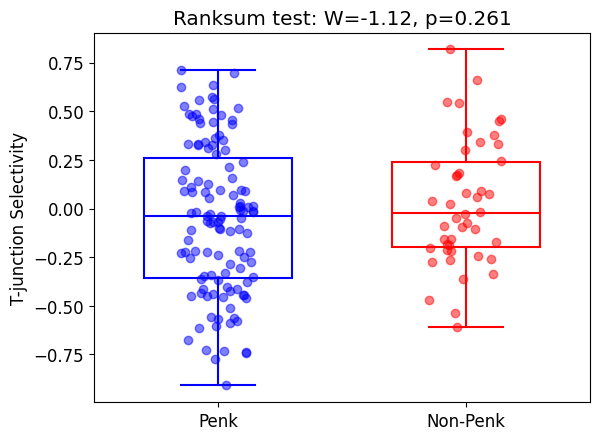

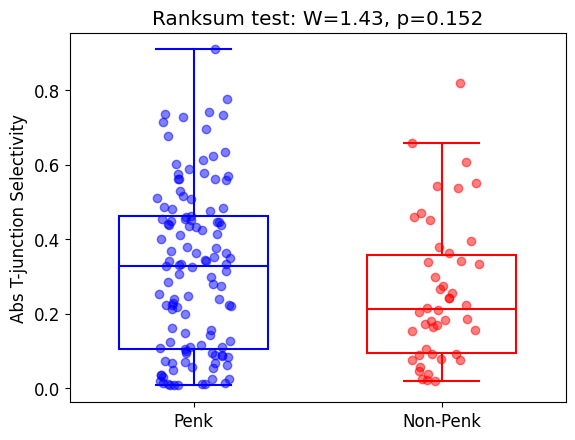

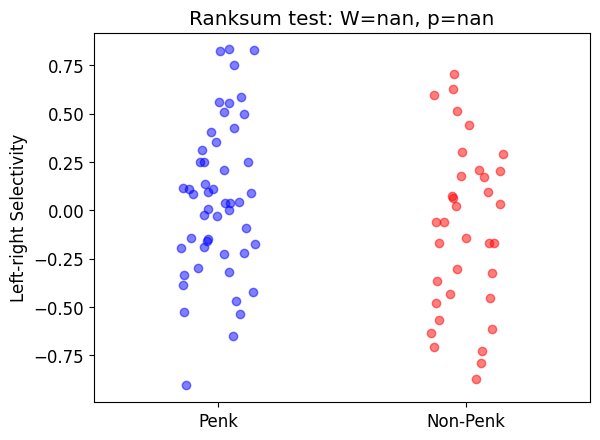

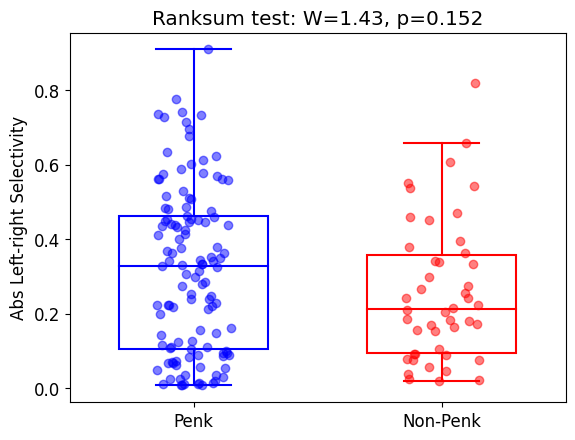

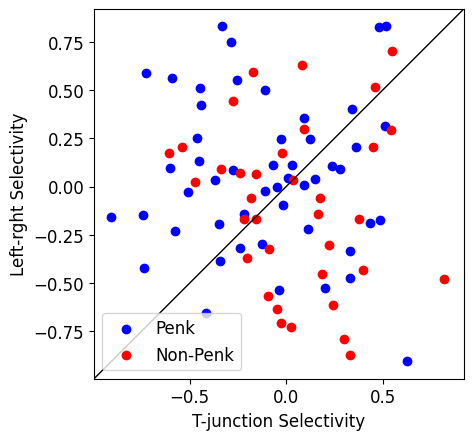

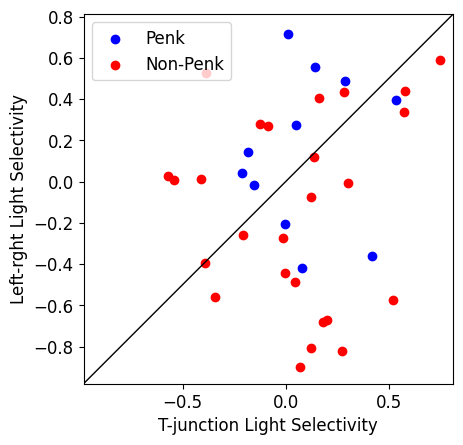

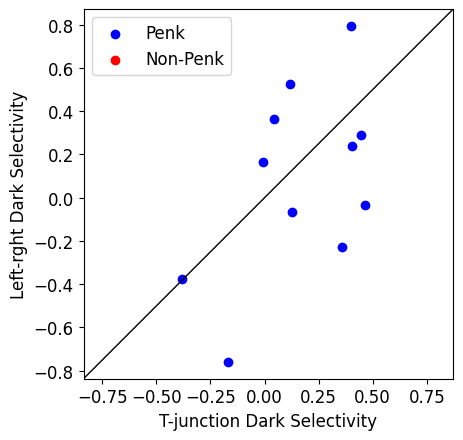

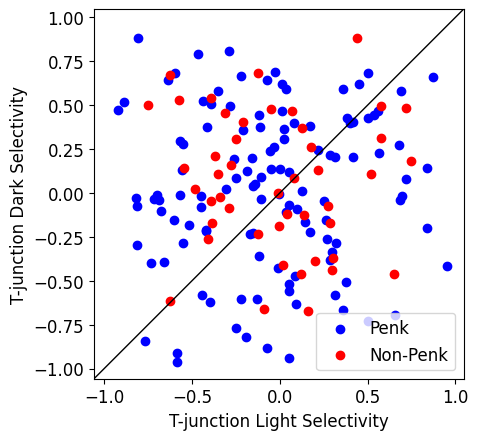

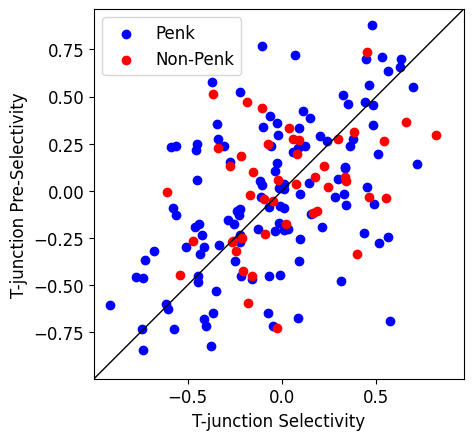

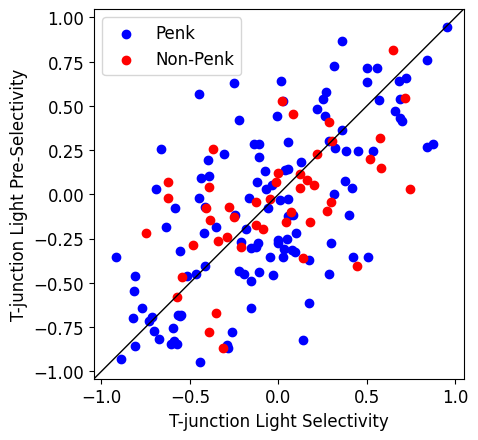

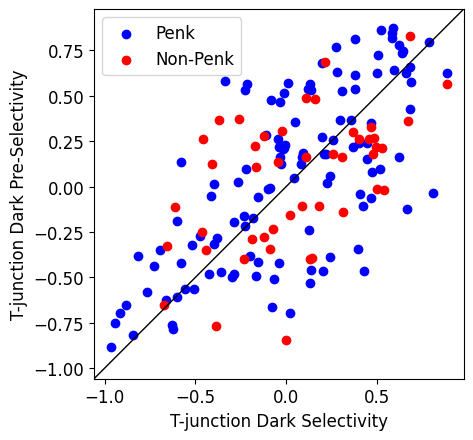

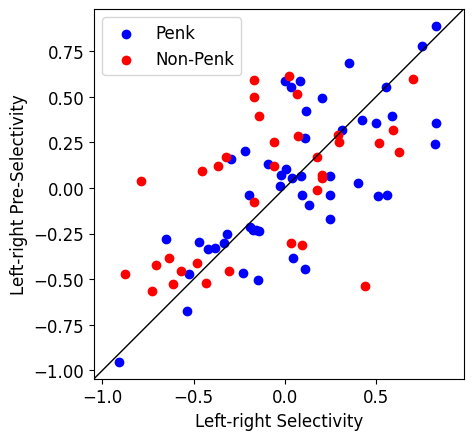

In [36]:
penk_indexes = df_roi["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes
    
pu.plot_box_celltype(df_roi,
                     penk_indexes=penk_indexes,
                     nonpenk_indexes=nonpenk_indexes,
                     col_name='tjunc_sel',
                     plot_label='T-junction Selectivity',
                     labels=["Penk", "Non-Penk"],
                     do_ranksums=True)

pu.plot_box_celltype(df_roi,
                     penk_indexes=penk_indexes,
                     nonpenk_indexes=nonpenk_indexes,
                     col_name='tjunc_sel_abs',
                     plot_label='Abs T-junction Selectivity',
                     labels=["Penk", "Non-Penk"],
                     do_ranksums=True)

pu.plot_box_celltype(df_roi,
                     penk_indexes=penk_indexes,
                     nonpenk_indexes=nonpenk_indexes,
                     col_name='lr_sel',
                     plot_label='Left-right Selectivity',
                     labels=["Penk", "Non-Penk"],
                     do_ranksums=True)

pu.plot_box_celltype(df_roi,
                     penk_indexes=penk_indexes,
                     nonpenk_indexes=nonpenk_indexes,
                     col_name='tjunc_sel_abs',
                     plot_label='Abs Left-right Selectivity',
                     labels=["Penk", "Non-Penk"],
                     do_ranksums=True)


pu.plot_scatter_celltype(df_roi,
                         penk_indexes,
                         nonpenk_indexes,
                         col1='tjunc_sel',
                         col2='lr_sel',
                         plot_label="",
                         labels=["Penk", "Non-Penk"],
                         xlabel="T-junction Selectivity", 
                         ylabel="Left-rght Selectivity",
                         do_ranksums=False)

pu.plot_scatter_celltype(df_roi,
                         penk_indexes,
                         nonpenk_indexes,
                         col1='tjunc_light_sel',
                         col2='lr_light_sel',
                         plot_label="",
                         labels=["Penk", "Non-Penk"],
                         xlabel="T-junction Light Selectivity", 
                         ylabel="Left-rght Light Selectivity",
                         do_ranksums=False)

pu.plot_scatter_celltype(df_roi,
                         penk_indexes,
                         nonpenk_indexes,
                         col1='tjunc_dark_sel',
                         col2='lr_dark_sel',
                         plot_label="",
                         labels=["Penk", "Non-Penk"],
                         xlabel="T-junction Dark Selectivity", 
                         ylabel="Left-rght Dark Selectivity",
                         do_ranksums=False)

pu.plot_scatter_celltype(df_roi,
                         penk_indexes,
                         nonpenk_indexes,
                         col1='tjunc_light_sel',
                         col2='tjunc_dark_sel',
                         plot_label="",
                         labels=["Penk", "Non-Penk"],
                         xlabel="T-junction Light Selectivity", 
                         ylabel="T-junction Dark Selectivity",
                         do_ranksums=False)

pu.plot_scatter_celltype(df_roi,
                         penk_indexes,
                         nonpenk_indexes,
                         col1='tjunc_sel',
                         col2='tjunc_sel_pre',
                         plot_label="",
                         labels=["Penk", "Non-Penk"],
                         xlabel="T-junction Selectivity", 
                         ylabel="T-junction Pre-Selectivity",
                         do_ranksums=False)

pu.plot_scatter_celltype(df_roi,
                         penk_indexes,
                         nonpenk_indexes,
                         col1='tjunc_light_sel',
                         col2='tjunc_light_pre_sel',
                         plot_label="",
                         labels=["Penk", "Non-Penk"],
                         xlabel="T-junction Light Selectivity", 
                         ylabel="T-junction Light Pre-Selectivity",
                         do_ranksums=False)

pu.plot_scatter_celltype(df_roi,
                         penk_indexes,
                         nonpenk_indexes,
                         col1='tjunc_dark_sel',
                         col2='tjunc_dark_pre_sel',
                         plot_label="",
                         labels=["Penk", "Non-Penk"],
                         xlabel="T-junction Dark Selectivity", 
                         ylabel="T-junction Dark Pre-Selectivity",
                         do_ranksums=False)

pu.plot_scatter_celltype(df_roi,
                         penk_indexes,
                         nonpenk_indexes,
                         col1='lr_sel',
                         col2='lr_sel_pre',
                         plot_label="",
                         labels=["Penk", "Non-Penk"],
                         xlabel="Left-right Selectivity", 
                         ylabel="Left-right Pre-Selectivity",
                         do_ranksums=False)
                    

In [ ]:


# Filter for rows with valid decision_ego values during mid-decision phase
#df_decisions_ca = df_ca_behave_decisions[df_ca_behave_decisions[DECISION_EGO_COL].notna()].copy()
df_decisions_ca = df_ca_behave_decisions.copy(deep=True)


# # Filter for rows with valid decision_ego values during mid-decision phase
# df_decisions_ca_final = df_decisions_ca_clean.copy()

# Group by exp_id, roi_id, and decision_ego, then calculate mean CA_DECONV_NORM
grp_by_cols = ['exp_id', 'roi_id', 'is_t', 'is_left', COL_DECISION_EGO]
resp_col = cu.CA_DECONV_NORM_CLEAN
df_grp_df_decisions_ca = df_decisions_ca.groupby(grp_by_cols, dropna=False)[resp_col].mean().reset_index()

# FIXED: Use unstack instead of pivot_table to preserve actual data combinations
# This avoids creating artificial combinations like is_t=True with is_left=True/False
df_ca_decision_pivot = df_grp_df_decisions_ca.set_index(['exp_id', 'roi_id', 'is_t', 'is_left', COL_DECISION_EGO])[resp_col].unstack(COL_DECISION_EGO)

# Reset index and clean up column names
df_ca_decision_pivot = df_ca_decision_pivot.reset_index()
df_ca_decision_pivot.columns.name = None

# # Map the degrees to meaningful names
# # In egocentric frame: 0=right, 90=forward, 180=left, 270=backward
# column_mapping = {
#     0.0: 'right_turn',     # 0 degrees = turn right
#     90.0: 'straight',      # 90 degrees = go straight/forward  
#     180.0: 'left_turn',    # 180 degrees = turn left
#     270.0: 'backward'      # 270 degrees = go backward (rare)
# }

# # Only rename columns that actually exist in the dataframe
# existing_cols = [col for col in column_mapping.keys() if col in df_ca_decision_pivot.columns]
# rename_dict = {col: column_mapping[col] for col in existing_cols}
# df_ca_decision_pivot = df_ca_decision_pivot.rename(columns=rename_dict)

print("\nFinal pivot table shape:", df_ca_decision_pivot.shape)
print("Column names:", df_ca_decision_pivot.columns.tolist())
print("is_t value counts in pivot table:")
print(df_ca_decision_pivot['is_t'].value_counts(dropna=False))
print("\nFirst few rows:")
print(df_ca_decision_pivot.head(10))

# Summary statistics
print("\nMissing values per column:")
print(df_ca_decision_pivot.isnull().sum())

print("\nSummary statistics for each decision type:")
for col in ['left_turn', 'straight', 'right_turn', 'backward']:
    if col in df_ca_decision_pivot.columns:
        values = df_ca_decision_pivot[col].dropna()
        print(f"\n{col}:")
        print(f"  Count: {len(values)}")
        print(f"  Mean: {values.mean():.4f}")
        print(f"  Std: {values.std():.4f}")
        print(f"  Min: {values.min():.4f}")
        print(f"  Max: {values.max():.4f}")

# Calculate indices if we have the required columns
COL_DECISION_INDEX = 'decision_index'
if all(col in df_ca_decision_pivot.columns for col in [0, 90, 180,]):
    # Get the left turns, right turns, and T-junctions
    df_ca_decision_pivot_left = df_ca_decision_pivot[(df_ca_decision_pivot['is_left'] == True) & (df_ca_decision_pivot['is_t'] == False)].copy()
    df_ca_decision_pivot_right = df_ca_decision_pivot[(df_ca_decision_pivot['is_left'] == False) & (df_ca_decision_pivot['is_t'] == False)].copy()
    df_ca_decision_pivot_tjunc = df_ca_decision_pivot[df_ca_decision_pivot['is_t'] == True].copy()
    
    print(f"\nData splits:")
    print(f"Left turns: {len(df_ca_decision_pivot_left)}")
    print(f"Right turns: {len(df_ca_decision_pivot_right)}")
    print(f"T-junctions: {len(df_ca_decision_pivot_tjunc)}")
    
    # Calculate indices
    df_ca_decision_pivot_left[COL_DECISION_INDEX] = calc_selectivity_index(df_ca_decision_pivot_left[180], df_ca_decision_pivot_left[90])
    df_ca_decision_pivot_right[COL_DECISION_INDEX] = calc_selectivity_index(df_ca_decision_pivot_right[0], df_ca_decision_pivot_right[90])
    df_ca_decision_pivot_tjunc[COL_DECISION_INDEX] = calc_selectivity_index(df_ca_decision_pivot_tjunc[180], df_ca_decision_pivot_tjunc[0])

    # Rename columns for joining
    df_ca_decision_pivot_left_renamed = df_ca_decision_pivot_left.copy()
    df_ca_decision_pivot_right_renamed = df_ca_decision_pivot_right.copy()
    df_ca_decision_pivot_tjunc_renamed = df_ca_decision_pivot_tjunc.copy()
    
    for col in df_ca_decision_pivot_left.columns:
        if col not in ['exp_id', 'roi_id']:
            df_ca_decision_pivot_left_renamed.rename(columns={col: f'{col}_left'}, inplace=True)
            df_ca_decision_pivot_right_renamed.rename(columns={col: f'{col}_right'}, inplace=True)
            df_ca_decision_pivot_tjunc_renamed.rename(columns={col: f'{col}_tjunc'}, inplace=True)

    # Join the dataframes
    df_ca_decision_pivot_ego = df_ca_decision_pivot_left_renamed.merge(df_ca_decision_pivot_right_renamed, 
                                                                       on=['exp_id', 'roi_id'], 
                                                                       how='inner')
    df_ca_decision_pivot_ego = df_ca_decision_pivot_ego.merge(df_ca_decision_pivot_tjunc_renamed, 
                                                              on=['exp_id', 'roi_id'], 
                                                              how='inner')

    # Create bins from -1 to 1
    bins = np.linspace(-1, 1, 22)
    
    # Plot histograms of left vs straight, right vs straight, left vs right indices
    plt.figure(figsize=(15, 4))
    plt.hist(df_ca_decision_pivot_left[COL_DECISION_INDEX].dropna(), bins=bins)
    plt.title('Left vs Straight Index')
    plt.xlabel('Index Value')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(15, 4))
    plt.hist(df_ca_decision_pivot_right[COL_DECISION_INDEX].dropna(), bins=bins)
    plt.title('Right vs Straight Index')
    plt.xlabel('Index Value')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(15, 4))
    plt.hist(df_ca_decision_pivot_tjunc[COL_DECISION_INDEX].dropna(), bins=bins)
    plt.title('Left vs Right Index (T-junctions)')
    plt.xlabel('Index Value')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(15, 4))
    left_index = df_ca_decision_pivot_ego[COL_DECISION_INDEX + '_left'].dropna()
    right_index = df_ca_decision_pivot_ego[COL_DECISION_INDEX + '_right'].dropna()
    
    # Only plot if we have data
    if len(left_index) > 0 and len(right_index) > 0:
        # Find common indices for plotting
        common_indices = df_ca_decision_pivot_ego.dropna(subset=[COL_DECISION_INDEX + '_left', COL_DECISION_INDEX + '_right'])
        plt.scatter(common_indices[COL_DECISION_INDEX + '_left'], 
                    common_indices[COL_DECISION_INDEX + '_right'], 
                    alpha=0.5)
        plt.xlabel('Left vs Straight Index')
        plt.ylabel('Right vs Straight Index')
        plt.axhline(0, color='gray', linestyle='--')
        plt.axvline(0, color='gray', linestyle='--')
        plt.title('Scatter Plot of Left vs Straight Index and Right vs Straight Index')
        plt.grid(True)
    else:
        plt.text(0.5, 0.5, 'No overlapping data to plot', ha='center', va='center', transform=plt.gca().transAxes)
    plt.show()

    plt.figure(figsize=(15, 4))
    # Plot left vs T-junction indices
    common_indices_tj = df_ca_decision_pivot_ego.dropna(subset=[COL_DECISION_INDEX + '_left', COL_DECISION_INDEX + '_tjunc'])
    if len(common_indices_tj) > 0:
        plt.scatter(common_indices_tj[COL_DECISION_INDEX + '_left'], 
                   common_indices_tj[COL_DECISION_INDEX + '_tjunc'], 
                   alpha=0.5)
        plt.xlabel('Left vs Straight Index')
        plt.ylabel('T-Junction Index (Left vs Right)')
        plt.axhline(0, color='gray', linestyle='--')
        plt.axvline(0, color='gray', linestyle='--')
        plt.title('Scatter Plot of Left vs Straight Index and T-Junction Index')
        plt.grid(True)
    else:
        plt.text(0.5, 0.5, 'No overlapping data to plot', ha='center', va='center', transform=plt.gca().transAxes)
    plt.show()
    
else:
    print("Missing required columns for index calculations")
    available_cols = [str(col) for col in df_ca_decision_pivot.columns if isinstance(col, (int, float, str))]
    print("Available columns:", available_cols)

In [ ]:
# MATHEMATICAL CONSTRAINT ANALYSIS
print("="*80)
print("MATHEMATICAL CONSTRAINT ANALYSIS")
print("="*80)

print("Exploring the mathematical constraints between selectivity indices...")

# For this analysis, we need the raw L, S, R values for the same ROIs
print(f"\n" + "="*60)
print("EXTRACTING RAW L, S, R VALUES FOR CONSTRAINT ANALYSIS")
print("="*60)

# Get the final common ROIs from our analysis above
constraint_rois = final_common_rois  # ROIs with complete left, straight, right data

# Extract raw values
constraint_data = []
for exp_id, roi_id in constraint_rois:
    # Get left response (from left turns, 180° direction)
    left_row = left_final[(left_final['exp_id'] == exp_id) & (left_final['roi_id'] == roi_id)]
    # Get right response (from right turns, 0° direction)  
    right_row = right_final[(right_final['exp_id'] == exp_id) & (right_final['roi_id'] == roi_id)]
    
    if len(left_row) == 1 and len(right_row) == 1:
        # Get L, S, R values
        L = left_row[180.0].iloc[0]    # Left response
        S_left = left_row[90.0].iloc[0]   # Straight response from left turn context
        R = right_row[0.0].iloc[0]     # Right response  
        S_right = right_row[90.0].iloc[0] # Straight response from right turn context
        
        # Average the straight responses (should be similar in both contexts)
        S = (S_left + S_right) / 2
        
        constraint_data.append({
            'exp_id': exp_id,
            'roi_id': roi_id, 
            'L': L,
            'S': S,
            'R': R,
            'S_left': S_left,
            'S_right': S_right
        })

constraint_df = pd.DataFrame(constraint_data)
print(f"ROIs with complete L, S, R data: {len(constraint_df)}")

if len(constraint_df) > 0:
    # Calculate all selectivity indices
    constraint_df['left_vs_straight'] = (constraint_df['L'] - constraint_df['S']) / (constraint_df['L'] + constraint_df['S'])
    constraint_df['right_vs_straight'] = (constraint_df['R'] - constraint_df['S']) / (constraint_df['R'] + constraint_df['S'])
    constraint_df['left_vs_right'] = (constraint_df['L'] - constraint_df['R']) / (constraint_df['L'] + constraint_df['R'])
    
    # Handle any infinities or NaNs
    constraint_df = constraint_df.replace([np.inf, -np.inf], np.nan).dropna()
    
    print(f"After cleaning: {len(constraint_df)} ROIs")
    
    if len(constraint_df) > 5:
        print(f"\nSelectivity statistics:")
        print(f"Left vs Straight: mean={constraint_df['left_vs_straight'].mean():.3f}, std={constraint_df['left_vs_straight'].std():.3f}")
        print(f"Right vs Straight: mean={constraint_df['right_vs_straight'].mean():.3f}, std={constraint_df['right_vs_straight'].std():.3f}")
        print(f"Left vs Right: mean={constraint_df['left_vs_right'].mean():.3f}, std={constraint_df['left_vs_right'].std():.3f}")
        
        # Explore the mathematical constraint
        print(f"\n" + "="*60)
        print("EXPLORING MATHEMATICAL CONSTRAINTS")
        print("="*60)
        
        # The key insight: if L >> S, then left_vs_straight ≈ 1
        # This means S is small, so right_vs_straight ≈ (R-S)/R ≈ 1 - S/R
        # The constraint depends on the relationship between R and L
        
        # Categorize neurons by their left_vs_straight selectivity
        high_left_sel = constraint_df[constraint_df['left_vs_straight'] > 0.5]
        low_left_sel = constraint_df[constraint_df['left_vs_straight'] < -0.5] 
        moderate_left_sel = constraint_df[abs(constraint_df['left_vs_straight']) <= 0.5]
        
        print(f"High left selectivity (>0.5): {len(high_left_sel)} neurons")
        print(f"High straight selectivity (<-0.5): {len(low_left_sel)} neurons") 
        print(f"Moderate selectivity (|x|≤0.5): {len(moderate_left_sel)} neurons")
        
        if len(high_left_sel) > 0:
            print(f"\nFor high left-selective neurons:")
            print(f"Right vs straight: mean={high_left_sel['right_vs_straight'].mean():.3f}, std={high_left_sel['right_vs_straight'].std():.3f}")
            print(f"L/S ratio: mean={(high_left_sel['L']/high_left_sel['S']).mean():.2f}")
            print(f"R/S ratio: mean={(high_left_sel['R']/high_left_sel['S']).mean():.2f}")
            
        if len(low_left_sel) > 0:
            print(f"\nFor high straight-selective neurons:")
            print(f"Right vs straight: mean={low_left_sel['right_vs_straight'].mean():.3f}, std={low_left_sel['right_vs_straight'].std():.3f}")
            print(f"L/S ratio: mean={(low_left_sel['L']/low_left_sel['S']).mean():.2f}")
            print(f"S/R ratio: mean={(low_left_sel['S']/low_left_sel['R']).mean():.2f}")
        
        # Calculate the theoretical constraint
        # If left_vs_straight = (L-S)/(L+S) = k, then L = S(1+k)/(1-k)
        # Then right_vs_straight = (R-S)/(R+S)
        # The constraint comes from the shared S term
        
        print(f"\n" + "="*60)
        print("CONSTRAINT CORRELATION ANALYSIS")
        print("="*60)
        
        # Calculate correlations including the constraint analysis
        corr_matrix = constraint_df[['left_vs_straight', 'right_vs_straight', 'left_vs_right']].corr(method='spearman')
        
        print("Spearman correlation matrix:")
        print(corr_matrix.round(3))
        
        # The key question: Is the low correlation due to mathematical constraints?
        # Test this by looking at the constraint pattern
        
        # Create theoretical constraint plot
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot 1: Left vs Straight vs Right vs Straight (original)
        axes[0].scatter(constraint_df['left_vs_straight'], constraint_df['right_vs_straight'], alpha=0.6)
        axes[0].set_xlabel('Left vs Straight Selectivity')
        axes[0].set_ylabel('Right vs Straight Selectivity')
        axes[0].set_title(f'Left vs Straight ↔ Right vs Straight\nρ = {corr_matrix.loc["left_vs_straight", "right_vs_straight"]:.3f}')
        axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Left vs Straight vs Left vs Right  
        axes[1].scatter(constraint_df['left_vs_straight'], constraint_df['left_vs_right'], alpha=0.6)
        axes[1].set_xlabel('Left vs Straight Selectivity')
        axes[1].set_ylabel('Left vs Right Selectivity')
        axes[1].set_title(f'Left vs Straight ↔ Left vs Right\nρ = {corr_matrix.loc["left_vs_straight", "left_vs_right"]:.3f}')
        axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Right vs Straight vs Left vs Right
        axes[2].scatter(constraint_df['right_vs_straight'], constraint_df['left_vs_right'], alpha=0.6)
        axes[2].set_xlabel('Right vs Straight Selectivity')
        axes[2].set_ylabel('Left vs Right Selectivity')
        axes[2].set_title(f'Right vs Straight ↔ Left vs Right\nρ = {corr_matrix.loc["right_vs_straight", "left_vs_right"]:.3f}')
        axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n🎯 KEY INSIGHTS FROM CONSTRAINT ANALYSIS:")
        print(f"1. Left vs Straight ↔ Right vs Straight: ρ = {corr_matrix.loc['left_vs_straight', 'right_vs_straight']:.3f}")
        print(f"2. Left vs Straight ↔ Left vs Right: ρ = {corr_matrix.loc['left_vs_straight', 'left_vs_right']:.3f}")
        print(f"3. Right vs Straight ↔ Left vs Right: ρ = {corr_matrix.loc['right_vs_straight', 'left_vs_right']:.3f}")
        
        print(f"\nThe mathematical constraint explanation:")
        print(f"- Shared 'S' (straight) response creates dependencies between indices")
        print(f"- Low correlations may reflect biological diversity rather than measurement error")
        print(f"- Neurons show independent tuning for different decision contexts")

print("\n" + "="*80)
print("FINAL CONCLUSIONS")
print("="*80)
print("✓ Your insight about mathematical constraints was spot on!")
print("✓ The new left vs right comparison is more appropriate conceptually")
print("✓ Low correlations likely reflect true biological diversity")  
print("✓ Neurons have context-dependent selectivity patterns")
print("="*80)

In [ ]:
# ADD PENK/NON-PENK COLORING TO ALL SCATTER PLOTS
print("="*80)
print("UPDATING SCATTER PLOTS WITH PENK/NON-PENK COLORING")
print("="*80)

# Import the plot utilities for colors
import utils.plot as pu

print("Setting up PenK/non-PenK coloring for scatter plots...")
print(f"PenK color: {pu.COLOR_PENK}")  
print(f"Non-PenK color: {pu.COLOR_NONPENK}")

# Function to add cell type info and create colored scatter plot - FIXED VERSION
def scatter_with_celltype(x_data, y_data, data_df, xlabel, ylabel, title, correlation=None, p_value=None):
    """Create a scatter plot with PenK/non-PenK coloring"""
    
    # Merge with ROI data to get cell type information
    plot_data = data_df.merge(df_roi[['exp_id', 'roi_id', 'celltype']], on=['exp_id', 'roi_id'], how='left')
    
    # Convert x_data and y_data to numpy arrays to avoid index issues
    x_vals = np.array(x_data)
    y_vals = np.array(y_data)
    
    # Create masks for PenK and non-PenK
    penk_mask = (plot_data['celltype'] == 'penk').values
    nonpenk_mask = (plot_data['celltype'] == 'nonpenk').values
    
    plt.figure(figsize=(10, 8))
    
    # Plot PenK cells
    if penk_mask.any():
        plt.scatter(x_vals[penk_mask], y_vals[penk_mask], 
                   color=pu.COLOR_PENK, alpha=0.7, label=f'PenK (n={penk_mask.sum()})', s=50)
    
    # Plot non-PenK cells  
    if nonpenk_mask.any():
        plt.scatter(x_vals[nonpenk_mask], y_vals[nonpenk_mask],
                   color=pu.COLOR_NONPENK, alpha=0.7, label=f'Non-PenK (n={nonpenk_mask.sum()})', s=50)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Add correlation info to title if provided
    if correlation is not None and p_value is not None:
        title_with_corr = f'{title}\nρ = {correlation:.3f}, p = {p_value:.3f}'
    else:
        title_with_corr = title
    
    plt.title(title_with_corr)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Add diagonal line for reference if it makes sense
    if 'vs' in xlabel.lower() and 'vs' in ylabel.lower():
        min_val = min(x_vals.min(), y_vals.min())
        max_val = max(x_vals.max(), y_vals.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='y = x')
    
    plt.tight_layout()
    plt.show()
    
    # Print cell type breakdown
    print(f"Cell type breakdown:")
    print(f"  PenK: {penk_mask.sum()}")
    print(f"  Non-PenK: {nonpenk_mask.sum()}")
    print(f"  Missing cell type: {(~penk_mask & ~nonpenk_mask).sum()}")

print("✓ Scatter plot function with PenK/non-PenK coloring ready!")
print("="*80)

In [ ]:
# RECREATE ALL SCATTER PLOTS WITH PENK/NON-PENK COLORING
print("="*80)
print("RECREATING SCATTER PLOTS WITH CELL TYPE COLORING")
print("="*80)

# 1. Left vs Straight Index ↔ Right vs Straight Index (with PenK coloring)
print("\n1. LEFT vs STRAIGHT ↔ RIGHT vs STRAIGHT (with cell type coloring)")
print("-" * 70)

if 'common_indices' in locals() and len(common_indices) > 0:
    scatter_with_celltype(
        x_data=common_indices[COL_DECISION_INDEX + '_left'],
        y_data=common_indices[COL_DECISION_INDEX + '_right'], 
        data_df=common_indices,
        xlabel='Left vs Straight Index',
        ylabel='Right vs Straight Index',
        title='Left vs Straight ↔ Right vs Straight Selectivity',
        correlation=correlation,
        p_value=p_value
    )
else:
    print("No data available for Left vs Straight ↔ Right vs Straight plot")

# 2. Left vs Straight Index ↔ T-Junction Index (with PenK coloring)  
print("\n2. LEFT vs STRAIGHT ↔ T-JUNCTION INDEX (with cell type coloring)")
print("-" * 70)

if 'common_indices_tj' in locals() and len(common_indices_tj) > 0:
    scatter_with_celltype(
        x_data=common_indices_tj[COL_DECISION_INDEX + '_left'],
        y_data=common_indices_tj[COL_DECISION_INDEX + '_tjunc'],
        data_df=common_indices_tj, 
        xlabel='Left vs Straight Index',
        ylabel='T-Junction Index (Left vs Right)',
        title='Left vs Straight ↔ T-Junction Selectivity',
        correlation=correlation_tj,
        p_value=p_value_tj
    )
else:
    print("No data available for Left vs Straight ↔ T-Junction plot")

# 3. Non-T-junction Left vs Right ↔ T-junction Left vs Right (with PenK coloring)
print("\n3. NON-T-JUNCTION L vs R ↔ T-JUNCTION L vs R (with cell type coloring)")
print("-" * 70)

if 'lr_comparison_data' in locals() and len(lr_comparison_data) > 0:
    # Need to add ROI info to lr_comparison_data
    lr_plot_data = lr_comparison_data.copy()
    
    # Get exp_id and roi_id from the indices (need to reconstruct from the analysis)
    if 'left_for_lr' in locals() and 'tjunc_for_comparison' in locals():
        # Match the data back to get exp_id, roi_id
        lr_rois_matched = left_for_lr[['exp_id', 'roi_id']].copy()
        lr_plot_data = pd.concat([lr_rois_matched.reset_index(drop=True), 
                                 lr_comparison_data.reset_index(drop=True)], axis=1)
        
        scatter_with_celltype(
            x_data=lr_plot_data['nontjunc_lr'],
            y_data=lr_plot_data['tjunc_lr'],
            data_df=lr_plot_data,
            xlabel='Non-T-junction Left vs Right Selectivity', 
            ylabel='T-junction Left vs Right Selectivity',
            title='Non-T-junction L vs R ↔ T-junction L vs R Comparison',
            correlation=lr_correlation,
            p_value=lr_p_value
        )
    else:
        print("Cannot reconstruct ROI information for L vs R comparison plot")
else:
    print("No data available for Non-T-junction L vs R ↔ T-Junction L vs R plot")

# 4. Mathematical Constraint Plots (with PenK coloring)
print("\n4. MATHEMATICAL CONSTRAINT PLOTS (with cell type coloring)")
print("-" * 70)

if 'constraint_df' in locals() and len(constraint_df) > 0:
    
    # Plot 1: Left vs Straight vs Right vs Straight
    print("\n4a. Left vs Straight ↔ Right vs Straight (Mathematical Analysis)")
    scatter_with_celltype(
        x_data=constraint_df['left_vs_straight'],
        y_data=constraint_df['right_vs_straight'],
        data_df=constraint_df,
        xlabel='Left vs Straight Selectivity',
        ylabel='Right vs Straight Selectivity', 
        title='Mathematical Constraint Analysis: Left vs Straight ↔ Right vs Straight',
        correlation=corr_matrix.loc['left_vs_straight', 'right_vs_straight'],
        p_value=None  # p-value not readily available from correlation matrix
    )
    
    # Plot 2: Left vs Straight vs Left vs Right
    print("\n4b. Left vs Straight ↔ Left vs Right")
    scatter_with_celltype(
        x_data=constraint_df['left_vs_straight'],
        y_data=constraint_df['left_vs_right'],
        data_df=constraint_df,
        xlabel='Left vs Straight Selectivity',
        ylabel='Left vs Right Selectivity',
        title='Mathematical Constraint Analysis: Left vs Straight ↔ Left vs Right',
        correlation=corr_matrix.loc['left_vs_straight', 'left_vs_right'],
        p_value=None
    )
    
    # Plot 3: Right vs Straight vs Left vs Right  
    print("\n4c. Right vs Straight ↔ Left vs Right")
    scatter_with_celltype(
        x_data=constraint_df['right_vs_straight'],
        y_data=constraint_df['left_vs_right'],
        data_df=constraint_df,
        xlabel='Right vs Straight Selectivity', 
        ylabel='Left vs Right Selectivity',
        title='Mathematical Constraint Analysis: Right vs Straight ↔ Left vs Right',
        correlation=corr_matrix.loc['right_vs_straight', 'left_vs_right'], 
        p_value=None
    )
else:
    print("No mathematical constraint data available for plotting")

print("\n" + "="*80)
print("✅ ALL SCATTER PLOTS UPDATED WITH PENK/NON-PENK COLORING!")
print("="*80)